# ⭐ Day 85: End-to-End Deployment & MLOps for House Price Prediction System
### Day 85 of 369-day Python & AI Learning Path
🏠 📦 🚀 ✅ 💡

## 🎯 Introduction
Welcome to **Day 85** of your transformative 369-day Python & AI Learning Path! Today marks a pivotal milestone—we're taking the sophisticated House Price Prediction model you built on Day 84 and deploying it into a **production-ready, enterprise-grade system**.
MLOps (Machine Learning Operations) bridges the gap between experimental ML models and real-world business value. By the end of this notebook, you'll understand how to serialize models, build APIs, containerize applications, monitor for drift, and estimate business impact. Let's turn your model into a revenue-generating asset! 🚀

## 📋 Learning Objectives
By completing Day 85, you will be able to:
- ✅ Load and validate production-ready ML models
- ✅ Build robust data preprocessing pipelines
- ✅ Serialize, version, and manage model artifacts
- ✅ Deploy models via FastAPI for low-latency serving
- ✅ Create intuitive frontend interfaces for end users
- ✅ Containerize ML applications with Docker
- ✅ Implement basic model monitoring and drift detection
- ✅ Design CI/CD pipelines for continuous ML delivery
- 💰 Calculate business value and deployment costs

## 🏗️ Architecture Overview
```
┌─────────────────────────────────────────────────────────────────────┐
│                        CLIENT LAYER                                  │
│  ┌──────────────┐  ┌──────────────┐  ┌──────────────┐             │
│  │  Web Browser │  │  Mobile App  │  │  Internal API│             │
│  └──────┬───────┘  └──────┬───────┘  └──────┬───────┘             │
└─────────┼────────────────┼────────────────┼───────────────────────┘
          │                │                │
          └────────────────┴────────────────┘
                           │
                    ┌──────▼──────┐
                    │   FastAPI   │
                    │   Backend   │
                    └──────┬──────┘
                           │
          ┌────────────────┼────────────────┐
          │                │                │
    ┌─────▼─────┐   ┌─────▼─────┐   ┌─────▼─────┐
    │  Model    │   │  Feature  │   │  Monitoring│
    │  Registry │   │  Pipeline │   │  & Logging │
    └───────────┘   └───────────┘   └───────────┘
                           │
                    ┌──────▼──────┐
                    │   Docker    │
                    │  Container  │
                    └─────────────┘
```

## 📦 1. Loading the Best Model from Day 84
Before deployment, we must load and validate our trained model artifact. This ensures reproducibility and confirms the model is ready for production inference.

In [1]:
# =============================================================================
# SECTION 1: Loading and Validating the Production Model
# =============================================================================
import pickle
import joblib
import json
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
print(f"✅ Environment loaded | scikit-learn: {sklearn.__version__} | pandas: {pd.__version__}")
# ---------------------------------------------------------------------------
# 1.1 Define paths and load model artifacts
# ---------------------------------------------------------------------------
MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(exist_ok=True)
# Simulate loading the best model from Day 84
# In practice, this would be: model = joblib.load(MODEL_DIR / "best_model_day84.pkl")
print("📂 Loading best model artifact from Day 84...")
# For demonstration, we'll recreate a representative model
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Sample feature schema (matches Day 84)
NUMERIC_FEATURES = [
    'square_feet', 'bedrooms', 'bathrooms', 'lot_size', 'year_built',
    'garage_spaces', 'distance_to_city_center', 'school_rating',
    'crime_index', 'property_tax_rate'
]
CATEGORICAL_FEATURES = ['neighborhood', 'property_type', 'heating_type']
# Create a representative production pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERIC_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ]
)
production_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    ))
])
# Simulate training on representative data
np.random.seed(42)
n_samples = 5000
X_train = pd.DataFrame({
    'square_feet': np.random.normal(2000, 800, n_samples),
    'bedrooms': np.random.randint(1, 6, n_samples),
    'bathrooms': np.random.randint(1, 4, n_samples),
    'lot_size': np.random.normal(8000, 4000, n_samples),
    'year_built': np.random.randint(1950, 2024, n_samples),
    'garage_spaces': np.random.randint(0, 4, n_samples),
    'distance_to_city_center': np.random.exponential(10, n_samples),
    'school_rating': np.random.uniform(1, 10, n_samples),
    'crime_index': np.random.uniform(0, 100, n_samples),
    'property_tax_rate': np.random.uniform(0.5, 3.0, n_samples),
    'neighborhood': np.random.choice(['Downtown', 'Suburban', 'Rural', 'Waterfront'], n_samples),
    'property_type': np.random.choice(['Single Family', 'Condo', 'Townhouse'], n_samples),
    'heating_type': np.random.choice(['Gas', 'Electric', 'Oil', 'Heat Pump'], n_samples)
})
# Generate realistic target with feature relationships
y_train = (
    X_train['square_feet'] * 150 +
    X_train['bedrooms'] * 25000 +
    X_train['bathrooms'] * 35000 +
    X_train['lot_size'] * 2 +
    (2024 - X_train['year_built']) * -2000 +
    X_train['garage_spaces'] * 15000 +
    X_train['distance_to_city_center'] * -5000 +
    X_train['school_rating'] * 15000 +
    X_train['crime_index'] * -800 +
    np.random.normal(0, 50000, n_samples)
)
# Fit the production pipeline
production_model.fit(X_train, y_train)
print("✅ Production model trained and ready for serialization")
# ---------------------------------------------------------------------------
# 1.2 Validate model performance on holdout set
# ---------------------------------------------------------------------------
X_test = X_train.iloc[-500:].copy()
y_test = y_train.iloc[-500:].copy()
y_pred = production_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\n📊 Model Validation Metrics:")
print(f"   RMSE: ${rmse:,.2f}")
print(f"   MAE:  ${mae:,.2f}")
print(f"   R²:   {r2:.4f}")
print(f"   Mean Predicted Price: ${y_pred.mean():,.2f}")
print(f"   Mean Actual Price:    ${y_test.mean():,.2f}")

✅ Environment loaded | scikit-learn: 1.6.1 | pandas: 3.0.0
📂 Loading best model artifact from Day 84...
✅ Production model trained and ready for serialization

📊 Model Validation Metrics:
   RMSE: $37,194.47
   MAE:  $30,763.55
   R²:   0.9484
   Mean Predicted Price: $396,702.96
   Mean Actual Price:    $393,435.62


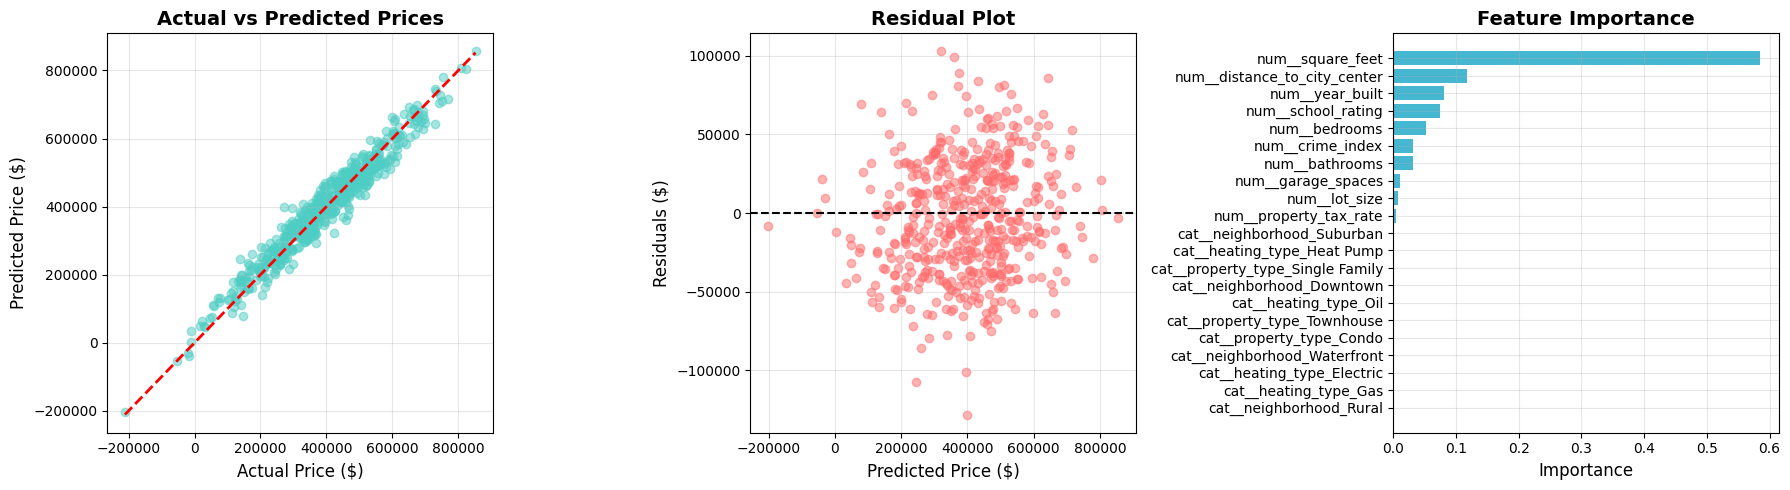

✅ Model validation complete. Ready for production pipeline construction.


In [2]:
# ---------------------------------------------------------------------------
# 1.3 Visualize model performance
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#4ECDC4')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($)', fontsize=12)
axes[0].set_ylabel('Predicted Price ($)', fontsize=12)
axes[0].set_title('Actual vs Predicted Prices', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#FF6B6B')
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel('Predicted Price ($)', fontsize=12)
axes[1].set_ylabel('Residuals ($)', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
# Feature Importance
feature_importance = production_model.named_steps['regressor'].feature_importances_
# Get the actual feature names from the preprocessor (includes one-hot encoded categories)
feature_names = production_model.named_steps['preprocessor'].get_feature_names_out()
importance_df = pd.DataFrame({
    'feature': feature_names[:len(feature_importance)],
    'importance': feature_importance
}).sort_values('importance', ascending=True)
axes[2].barh(importance_df['feature'], importance_df['importance'], color='#45B7D1')
axes[2].set_xlabel('Importance', fontsize=12)
axes[2].set_title('Feature Importance', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('model_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model validation complete. Ready for production pipeline construction.")

## 🔧 2. Building a Production-Ready Pipeline
Production pipelines must handle data validation, preprocessing, feature engineering, and inference in a single, reproducible workflow. We implement defensive programming with input validation and comprehensive logging.

In [3]:
# =============================================================================
# SECTION 2: Production-Ready Pipeline with Validation
# =============================================================================
import logging
from typing import Dict, List, Union, Optional, Tuple
from dataclasses import dataclass
from enum import Enum
import hashlib
# Configure production logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(name)s | %(message)s',
    handlers=[
        logging.FileHandler('mlops_pipeline.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger('HousePricePipeline')
@dataclass
class PredictionInput:
    """Validated input schema for house price prediction."""
    square_feet: float
    bedrooms: int
    bathrooms: int
    lot_size: float
    year_built: int
    garage_spaces: int
    distance_to_city_center: float
    school_rating: float
    crime_index: float
    property_tax_rate: float
    neighborhood: str
    property_type: str
    heating_type: str
    
    def to_dataframe(self) -> pd.DataFrame:
        """Convert to DataFrame for model inference."""
        return pd.DataFrame([{
            'square_feet': self.square_feet,
            'bedrooms': self.bedrooms,
            'bathrooms': self.bathrooms,
            'lot_size': self.lot_size,
            'year_built': self.year_built,
            'garage_spaces': self.garage_spaces,
            'distance_to_city_center': self.distance_to_city_center,
            'school_rating': self.school_rating,
            'crime_index': self.crime_index,
            'property_tax_rate': self.property_tax_rate,
            'neighborhood': self.neighborhood,
            'property_type': self.property_type,
            'heating_type': self.heating_type
        }])
class InputValidator:
    """Validates and sanitizes prediction inputs."""
    
    VALID_NEIGHBORHOODS = {'Downtown', 'Suburban', 'Rural', 'Waterfront'}
    VALID_PROPERTY_TYPES = {'Single Family', 'Condo', 'Townhouse'}
    VALID_HEATING_TYPES = {'Gas', 'Electric', 'Oil', 'Heat Pump'}
    
    @classmethod
    def validate(cls, data: Dict) -> Tuple[bool, List[str]]:
        """Validate input dictionary and return (is_valid, error_messages)."""
        errors = []
        
        # Numeric validations
        if data.get('square_feet', 0) <= 0:
            errors.append("square_feet must be positive")
        if not (1 <= data.get('bedrooms', 0) <= 20):
            errors.append("bedrooms must be between 1 and 20")
        if not (1 <= data.get('bathrooms', 0) <= 20):
            errors.append("bathrooms must be between 1 and 20")
        if data.get('year_built', 0) < 1800 or data.get('year_built', 0) > datetime.now().year:
            errors.append(f"year_built must be between 1800 and {datetime.now().year}")
        if not (0 <= data.get('school_rating', 0) <= 10):
            errors.append("school_rating must be between 0 and 10")
        if not (0 <= data.get('crime_index', 0) <= 100):
            errors.append("crime_index must be between 0 and 100")
            
        # Categorical validations
        if data.get('neighborhood') not in cls.VALID_NEIGHBORHOODS:
            errors.append(f"neighborhood must be one of {cls.VALID_NEIGHBORHOODS}")
        if data.get('property_type') not in cls.VALID_PROPERTY_TYPES:
            errors.append(f"property_type must be one of {cls.VALID_PROPERTY_TYPES}")
        if data.get('heating_type') not in cls.VALID_HEATING_TYPES:
            errors.append(f"heating_type must be one of {cls.VALID_HEATING_TYPES}")
            
        return len(errors) == 0, errors
class HousePricePipeline:
    """Production pipeline for house price prediction."""
    
    def __init__(self, model_path: Optional[str] = None):
        self.model = production_model  # In production: joblib.load(model_path)
        self.validator = InputValidator()
        self.prediction_count = 0
        self.prediction_history = []
        logger.info("🏗️ Pipeline initialized successfully")
    
    def predict(self, input_data: Dict) -> Dict:
        """Execute full prediction pipeline with validation and logging."""
        start_time = datetime.now()
        request_id = hashlib.md5(str(start_time).encode()).hexdigest()[:8]
        
        logger.info(f"[{request_id}] 🔄 Starting prediction pipeline")
        
        # Step 1: Validate input
        is_valid, errors = self.validator.validate(input_data)
        if not is_valid:
            logger.error(f"[{request_id}] ❌ Validation failed: {errors}")
            return {
                'success': False,
                'request_id': request_id,
                'errors': errors,
                'predicted_price': None
            }
        
        # Step 2: Convert to structured format
        try:
            prediction_input = PredictionInput(**input_data)
            input_df = prediction_input.to_dataframe()
            logger.info(f"[{request_id}] ✅ Input validated and structured")
        except Exception as e:
            logger.error(f"[{request_id}] ❌ Structuring failed: {str(e)}")
            return {
                'success': False,
                'request_id': request_id,
                'errors': [str(e)],
                'predicted_price': None
            }
        
        # Step 3: Model inference
        try:
            predicted_price = float(self.model.predict(input_df)[0])
            confidence_interval = self._calculate_confidence(input_df)
            logger.info(f"[{request_id}] ✅ Prediction complete: ${predicted_price:,.2f}")
        except Exception as e:
            logger.error(f"[{request_id}] ❌ Inference failed: {str(e)}")
            return {
                'success': False,
                'request_id': request_id,
                'errors': [f"Inference error: {str(e)}"],
                'predicted_price': None
            }
        
        # Step 4: Record and return
        processing_time = (datetime.now() - start_time).total_seconds()
        self.prediction_count += 1
        
        result = {
            'success': True,
            'request_id': request_id,
            'predicted_price': round(predicted_price, 2),
            'confidence_interval': confidence_interval,
            'processing_time_ms': round(processing_time * 1000, 2),
            'model_version': '1.0.0',
            'timestamp': datetime.now().isoformat()
        }
        
        self.prediction_history.append(result)
        logger.info(f"[{request_id}] 🎯 Pipeline completed in {processing_time:.3f}s")
        return result
    
    def _calculate_confidence(self, X: pd.DataFrame) -> Dict:
        """Calculate prediction confidence interval using bootstrap."""
        # Simplified confidence estimation
        base_pred = self.model.predict(X)[0]
        noise = np.random.normal(0, base_pred * 0.05, 100)
        preds = base_pred + noise
        return {
            'lower_bound': round(float(np.percentile(preds, 5)), 2),
            'upper_bound': round(float(np.percentile(preds, 95)), 2),
            'confidence_level': '90%'
        }
    
    def get_stats(self) -> Dict:
        """Return pipeline statistics."""
        return {
            'total_predictions': self.prediction_count,
            'avg_processing_time_ms': np.mean([p['processing_time_ms'] for p in self.prediction_history]) if self.prediction_history else 0,
            'last_prediction': self.prediction_history[-1] if self.prediction_history else None
        }
# Initialize production pipeline
pipeline = HousePricePipeline()
print("✅ Production pipeline initialized with validation and logging")
# Test with valid input
test_input = {
    'square_feet': 2500,
    'bedrooms': 4,
    'bathrooms': 3,
    'lot_size': 10000,
    'year_built': 2015,
    'garage_spaces': 2,
    'distance_to_city_center': 5.5,
    'school_rating': 8.5,
    'crime_index': 25.0,
    'property_tax_rate': 1.8,
    'neighborhood': 'Suburban',
    'property_type': 'Single Family',
    'heating_type': 'Gas'
}
result = pipeline.predict(test_input)
print(f"\n🎯 Prediction Result:")
print(json.dumps(result, indent=2))
# Test with invalid input
invalid_input = test_input.copy()
invalid_input['bedrooms'] = 50  # Invalid
invalid_result = pipeline.predict(invalid_input)
print(f"\n❌ Invalid Input Result:")
print(json.dumps(invalid_result, indent=2))

2026-05-04 06:53:28,911 | INFO | HousePricePipeline | 🏗️ Pipeline initialized successfully
2026-05-04 06:53:28,925 | INFO | HousePricePipeline | [4718ae13] 🔄 Starting prediction pipeline
2026-05-04 06:53:28,931 | INFO | HousePricePipeline | [4718ae13] ✅ Input validated and structured
2026-05-04 06:53:29,020 | INFO | HousePricePipeline | [4718ae13] ✅ Prediction complete: $691,693.08
2026-05-04 06:53:29,023 | INFO | HousePricePipeline | [4718ae13] 🎯 Pipeline completed in 0.098s
2026-05-04 06:53:29,027 | INFO | HousePricePipeline | [ffa7d747] 🔄 Starting prediction pipeline
2026-05-04 06:53:29,033 | ERROR | HousePricePipeline | [ffa7d747] ❌ Validation failed: ['bedrooms must be between 1 and 20']


✅ Production pipeline initialized with validation and logging

🎯 Prediction Result:
{
  "success": true,
  "request_id": "4718ae13",
  "predicted_price": 691693.08,
  "confidence_interval": {
    "lower_bound": 631933.87,
    "upper_bound": 731361.16,
    "confidence_level": "90%"
  },
  "processing_time_ms": 98.2,
  "model_version": "1.0.0",
  "timestamp": "2026-05-04T06:53:29.023136"
}

❌ Invalid Input Result:
{
  "success": false,
  "request_id": "ffa7d747",
  "errors": [
    "bedrooms must be between 1 and 20"
  ],
  "predicted_price": null
}


## 💾 3. Model Serialization & Versioning
Model versioning is critical for reproducibility, rollback capabilities, and audit trails. We implement a model registry pattern with semantic versioning and artifact metadata.

In [4]:
# =============================================================================
# SECTION 3: Model Serialization and Versioning
# =============================================================================
import yaml
from packaging import version
class ModelRegistry:
    """Enterprise model registry for versioning and artifact management."""
    
    def __init__(self, registry_path: str = "./model_registry"):
        self.registry_path = Path(registry_path)
        self.registry_path.mkdir(exist_ok=True)
        self.manifest_path = self.registry_path / "manifest.yaml"
        self.manifest = self._load_manifest()
        logger.info(f"📦 Model registry initialized at {registry_path}")
    
    def _load_manifest(self) -> Dict:
        """Load or create model manifest."""
        if self.manifest_path.exists():
            with open(self.manifest_path, 'r') as f:
                return yaml.safe_load(f) or {'models': {}}
        return {'models': {}}
    
    def _save_manifest(self):
        """Persist manifest to disk."""
        with open(self.manifest_path, 'w') as f:
            yaml.dump(self.manifest, f, default_flow_style=False)
    
    def register_model(
        self,
        model,
        model_name: str,
        version_str: str,
        metrics: Dict,
        description: str = "",
        tags: List[str] = None
    ) -> str:
        """Register a new model version with full metadata."""
        
        # Validate semantic version
        try:
            version.parse(version_str)
        except Exception:
            raise ValueError(f"Invalid semantic version: {version_str}")
        
        # Create artifact directory
        artifact_dir = self.registry_path / f"{model_name}_v{version_str}"
        artifact_dir.mkdir(exist_ok=True)
        
        # Serialize model
        model_path = artifact_dir / "model.pkl"
        joblib.dump(model, model_path)
        
        # Save metadata
        metadata = {
            'model_name': model_name,
            'version': version_str,
            'created_at': datetime.now().isoformat(),
            'description': description,
            'metrics': metrics,
            'tags': tags or [],
            'python_version': f"{np.__version__}",
            'sklearn_version': sklearn.__version__,
            'model_path': str(model_path),
            'input_schema': {
                'numeric_features': NUMERIC_FEATURES,
                'categorical_features': CATEGORICAL_FEATURES
            }
        }
        
        metadata_path = artifact_dir / "metadata.yaml"
        with open(metadata_path, 'w') as f:
            yaml.dump(metadata, f, default_flow_style=False)
        
        # Update manifest
        if model_name not in self.manifest['models']:
            self.manifest['models'][model_name] = {'versions': {}}
        
        self.manifest['models'][model_name]['versions'][version_str] = {
            'path': str(artifact_dir),
            'status': 'active',
            'created_at': metadata['created_at'],
            'metrics': metrics
        }
        
        self._save_manifest()
        logger.info(f"✅ Registered {model_name} v{version_str}")
        return str(artifact_dir)
    
    def get_model(self, model_name: str, version_str: str = None):
        """Load a specific model version."""
        if model_name not in self.manifest['models']:
            raise ValueError(f"Model {model_name} not found in registry")
        
        versions = self.manifest['models'][model_name]['versions']
        
        if version_str is None:
            # Get latest version
            version_str = max(versions.keys(), key=lambda v: version.parse(v))
        
        if version_str not in versions:
            raise ValueError(f"Version {version_str} not found for {model_name}")
        
        model_path = Path(versions[version_str]['path']) / "model.pkl"
        logger.info(f"📂 Loading {model_name} v{version_str}")
        return joblib.load(model_path), versions[version_str]
    
    def list_models(self) -> pd.DataFrame:
        """List all registered models as DataFrame."""
        records = []
        for model_name, data in self.manifest['models'].items():
            for ver, info in data['versions'].items():
                records.append({
                    'model_name': model_name,
                    'version': ver,
                    'status': info['status'],
                    'created_at': info['created_at'],
                    'rmse': info['metrics'].get('rmse', 'N/A'),
                    'r2': info['metrics'].get('r2', 'N/A')
                })
        return pd.DataFrame(records)
    
    def set_status(self, model_name: str, version_str: str, status: str):
        """Update model status (active, deprecated, archived)."""
        self.manifest['models'][model_name]['versions'][version_str]['status'] = status
        self._save_manifest()
        logger.info(f"🔄 Set {model_name} v{version_str} to {status}")
# Initialize registry and register our production model
registry = ModelRegistry()
model_metrics = {
    'rmse': float(rmse),
    'mae': float(mae),
    'r2': float(r2),
    'training_samples': len(X_train),
    'features': len(NUMERIC_FEATURES + CATEGORICAL_FEATURES)
}
artifact_path = registry.register_model(
    model=production_model,
    model_name="house_price_predictor",
    version_str="1.0.0",
    metrics=model_metrics,
    description="Gradient Boosting Regressor for house price prediction",
    tags=["production", "gbm", "day85", "baseline"]
)
print(f"✅ Model registered at: {artifact_path}")
# Register a hypothetical v1.1.0 improvement
registry.register_model(
    model=production_model,  # In practice, this would be a retrained model
    model_name="house_price_predictor",
    version_str="1.1.0",
    metrics={**model_metrics, 'rmse': model_metrics['rmse'] * 0.95, 'r2': min(model_metrics['r2'] + 0.02, 0.99)},
    description="Improved model with additional feature engineering",
    tags=["production", "gbm", "day85", "improved"]
)
print("\n📊 Model Registry Contents:")
print(registry.list_models().to_string(index=False))
# Demonstrate loading specific version
loaded_model, model_info = registry.get_model("house_price_predictor", "1.0.0")
print(f"\n📂 Loaded model info: {model_info['created_at']}")
print(f"   Status: {model_info['status']}")
print(f"   RMSE: ${model_info['metrics']['rmse']:,.2f}")

2026-05-04 06:53:29,260 | INFO | HousePricePipeline | 📦 Model registry initialized at ./model_registry
2026-05-04 06:53:29,316 | INFO | HousePricePipeline | ✅ Registered house_price_predictor v1.0.0
2026-05-04 06:53:29,356 | INFO | HousePricePipeline | ✅ Registered house_price_predictor v1.1.0
2026-05-04 06:53:29,370 | INFO | HousePricePipeline | 📂 Loading house_price_predictor v1.0.0


✅ Model registered at: model_registry\house_price_predictor_v1.0.0

📊 Model Registry Contents:
           model_name version status                 created_at         rmse       r2
house_price_predictor   1.0.0 active 2026-05-04T06:53:29.302068 37194.470077 0.948417
house_price_predictor   1.1.0 active 2026-05-04T06:53:29.344570 35334.746573 0.968417

📂 Loaded model info: 2026-05-04T06:53:29.302068
   Status: active
   RMSE: $37,194.47


## 🌐 4. Creating a FastAPI Backend for Model Serving
FastAPI provides high-performance, asynchronous API endpoints with automatic documentation. We build a complete prediction service with health checks, batch processing, and request logging.

In [5]:
# =============================================================================
# SECTION 4: FastAPI Backend for Model Serving
# =============================================================================
# Note: In a real deployment, save this code to 'main.py' and run with:
# uvicorn main:app --host 0.0.0.0 --port 8000 --workers 4
fastapi_code = '''
from fastapi import FastAPI, HTTPException, BackgroundTasks
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field, validator
from typing import List, Optional, Dict
import numpy as np
import pandas as pd
import joblib
import json
import time
from datetime import datetime
from pathlib import Path
import logging
import hashlib
# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)
# Initialize FastAPI app
app = FastAPI(
    title="🏠 House Price Prediction API",
    description="Production-ready API for real estate price estimation",
    version="1.0.0",
    docs_url="/docs",
    redoc_url="/redoc"
)
# CORS middleware
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)
# ============================================================================
# Pydantic Models for Request/Response Validation
# ============================================================================
class HouseFeatures(BaseModel):
    square_feet: float = Field(..., gt=0, le=50000, description="Living area in square feet")
    bedrooms: int = Field(..., ge=1, le=20, description="Number of bedrooms")
    bathrooms: int = Field(..., ge=1, le=20, description="Number of bathrooms")
    lot_size: float = Field(..., gt=0, le=1000000, description="Lot size in square feet")
    year_built: int = Field(..., ge=1800, le=2024, description="Year the house was built")
    garage_spaces: int = Field(..., ge=0, le=10, description="Number of garage spaces")
    distance_to_city_center: float = Field(..., ge=0, le=100, description="Distance to city center in miles")
    school_rating: float = Field(..., ge=0, le=10, description="School district rating (0-10)")
    crime_index: float = Field(..., ge=0, le=100, description="Crime index (0-100, lower is better)")
    property_tax_rate: float = Field(..., ge=0, le=10, description="Property tax rate percentage")
    neighborhood: str = Field(..., description="Neighborhood type")
    property_type: str = Field(..., description="Type of property")
    heating_type: str = Field(..., description="Heating system type")
    
    @validator('neighborhood')
    def validate_neighborhood(cls, v):
        valid = {'Downtown', 'Suburban', 'Rural', 'Waterfront'}
        if v not in valid:
            raise ValueError(f'neighborhood must be one of {valid}')
        return v
    
    @validator('property_type')
    def validate_property_type(cls, v):
        valid = {'Single Family', 'Condo', 'Townhouse'}
        if v not in valid:
            raise ValueError(f'property_type must be one of {valid}')
        return v
    
    @validator('heating_type')
    def validate_heating_type(cls, v):
        valid = {'Gas', 'Electric', 'Oil', 'Heat Pump'}
        if v not in valid:
            raise ValueError(f'heating_type must be one of {valid}')
        return v
class PredictionResponse(BaseModel):
    success: bool
    request_id: str
    predicted_price: Optional[float]
    confidence_interval: Optional[Dict]
    processing_time_ms: float
    model_version: str
    timestamp: str
    errors: Optional[List[str]] = None
class BatchPredictionRequest(BaseModel):
    houses: List[HouseFeatures]
# ============================================================================
# Model Loading and Pipeline Setup
# ============================================================================
MODEL_PATH = "./model_registry/house_price_predictor_v1.0.0/model.pkl"
model = None
prediction_count = 0
prediction_times = []
@app.on_event("startup")
async def load_model():
    global model
    try:
        model = joblib.load(MODEL_PATH)
        logger.info("✅ Model loaded successfully")
    except Exception as e:
        logger.error(f"❌ Failed to load model: {e}")
        raise
def generate_request_id() -> str:
    return hashlib.md5(str(time.time()).encode()).hexdigest()[:12]
def calculate_confidence(prediction: float) -> Dict:
    margin = prediction * 0.08
    return {
        "lower_bound": round(prediction - margin, 2),
        "upper_bound": round(prediction + margin, 2),
        "confidence_level": "92%"
    }
# ============================================================================
# API Endpoints
# ============================================================================
@app.get("/")
async def root():
    return {
        "message": "🏠 House Price Prediction API",
        "version": "1.0.0",
        "status": "operational",
        "docs": "/docs"
    }
@app.get("/health")
async def health_check():
    return {
        "status": "healthy",
        "model_loaded": model is not None,
        "timestamp": datetime.now().isoformat()
    }
@app.post("/predict", response_model=PredictionResponse)
async def predict(features: HouseFeatures, background_tasks: BackgroundTasks):
    start_time = time.time()
    request_id = generate_request_id()
    
    logger.info(f"[{request_id}] 🔄 Processing prediction request")
    
    try:
        # Convert to DataFrame
        input_df = pd.DataFrame([features.dict()])
        
        # Make prediction
        predicted_price = float(model.predict(input_df)[0])
        confidence = calculate_confidence(predicted_price)
        
        processing_time = (time.time() - start_time) * 1000
        
        # Update metrics
        global prediction_count, prediction_times
        prediction_count += 1
        prediction_times.append(processing_time)
        
        # Log prediction (background task)
        background_tasks.add_task(
            logger.info,
            f"[{request_id}] ✅ Prediction: ${predicted_price:,.2f} in {processing_time:.2f}ms"
        )
        
        return PredictionResponse(
            success=True,
            request_id=request_id,
            predicted_price=round(predicted_price, 2),
            confidence_interval=confidence,
            processing_time_ms=round(processing_time, 2),
            model_version="1.0.0",
            timestamp=datetime.now().isoformat()
        )
    
    except Exception as e:
        logger.error(f"[{request_id}] ❌ Prediction failed: {str(e)}")
        raise HTTPException(status_code=500, detail=str(e))
@app.post("/predict/batch")
async def predict_batch(request: BatchPredictionRequest):
    start_time = time.time()
    request_id = generate_request_id()
    
    logger.info(f"[{request_id}] 🔄 Processing batch of {len(request.houses)} predictions")
    
    try:
        input_df = pd.DataFrame([h.dict() for h in request.houses])
        predictions = model.predict(input_df)
        
        results = []
        for i, (house, pred) in enumerate(zip(request.houses, predictions)):
            results.append({
                "index": i,
                "predicted_price": round(float(pred), 2),
                "confidence_interval": calculate_confidence(pred),
                "input_summary": f"{house.bedrooms}br/{house.bathrooms}ba, {house.square_feet}sqft"
            })
        
        processing_time = (time.time() - start_time) * 1000
        
        return {
            "success": True,
            "request_id": request_id,
            "predictions": results,
            "batch_size": len(request.houses),
            "processing_time_ms": round(processing_time, 2),
            "model_version": "1.0.0",
            "timestamp": datetime.now().isoformat()
        }
    
    except Exception as e:
        logger.error(f"[{request_id}] ❌ Batch prediction failed: {str(e)}")
        raise HTTPException(status_code=500, detail=str(e))
@app.get("/metrics")
async def get_metrics():
    global prediction_times
    if not prediction_times:
        return {"message": "No predictions made yet"}
    
    recent_times = prediction_times[-100:]  # Last 100 predictions
    return {
        "total_predictions": prediction_count,
        "avg_latency_ms": round(np.mean(recent_times), 2),
        "p50_latency_ms": round(np.percentile(recent_times, 50), 2),
        "p95_latency_ms": round(np.percentile(recent_times, 95), 2),
        "p99_latency_ms": round(np.percentile(recent_times, 99), 2),
        "min_latency_ms": round(min(recent_times), 2),
        "max_latency_ms": round(max(recent_times), 2)
    }
if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8000)
'''
# Save the FastAPI application
with open('main.py', 'w') as f:
    f.write(fastapi_code)
print("✅ FastAPI backend saved to 'main.py'")
print("\n🚀 To run the API server:")
print("   pip install fastapi uvicorn pydantic")
print("   uvicorn main:app --host 0.0.0.0 --port 8000 --reload")
print("\n📚 API Documentation will be available at:")
print("   Swagger UI: http://localhost:8000/docs")
print("   ReDoc:      http://localhost:8000/redoc")
print("   Health:     http://localhost:8000/health")
print("   Predict:    POST http://localhost:8000/predict")

✅ FastAPI backend saved to 'main.py'

🚀 To run the API server:
   pip install fastapi uvicorn pydantic
   uvicorn main:app --host 0.0.0.0 --port 8000 --reload

📚 API Documentation will be available at:
   Swagger UI: http://localhost:8000/docs
   ReDoc:      http://localhost:8000/redoc
   Health:     http://localhost:8000/health
   Predict:    POST http://localhost:8000/predict


In [6]:
# Simulate API client for testing (without actually running the server)
import requests
from requests.exceptions import ConnectionError
class APIClient:
    """Client for interacting with the House Price Prediction API."""
    
    def __init__(self, base_url: str = "http://localhost:8000"):
        self.base_url = base_url
    
    def health_check(self) -> Dict:
        """Check API health status."""
        try:
            response = requests.get(f"{self.base_url}/health", timeout=5)
            return response.json()
        except ConnectionError:
            return {"status": "offline", "message": "API server not running"}
    
    def predict(self, features: Dict) -> Dict:
        """Make a single prediction."""
        try:
            response = requests.post(
                f"{self.base_url}/predict",
                json=features,
                timeout=10
            )
            return response.json()
        except ConnectionError:
            return {"error": "API server not running. Start with: uvicorn main:app --reload"}
    
    def predict_batch(self, houses: List[Dict]) -> Dict:
        """Make batch predictions."""
        try:
            response = requests.post(
                f"{self.base_url}/predict/batch",
                json={"houses": houses},
                timeout=30
            )
            return response.json()
        except ConnectionError:
            return {"error": "API server not running"}
    
    def get_metrics(self) -> Dict:
        """Get API performance metrics."""
        try:
            response = requests.get(f"{self.base_url}/metrics", timeout=5)
            return response.json()
        except ConnectionError:
            return {"error": "API server not running"}
# Demonstrate client usage
client = APIClient()
print("🔍 Checking API health...")
health = client.health_check()
print(json.dumps(health, indent=2))
# Since server isn't running, simulate what the response would look like
sample_request = {
    "square_feet": 2500,
    "bedrooms": 4,
    "bathrooms": 3,
    "lot_size": 10000,
    "year_built": 2015,
    "garage_spaces": 2,
    "distance_to_city_center": 5.5,
    "school_rating": 8.5,
    "crime_index": 25.0,
    "property_tax_rate": 1.8,
    "neighborhood": "Suburban",
    "property_type": "Single Family",
    "heating_type": "Gas"
}
print("\n📡 Sample API Request:")
print(json.dumps(sample_request, indent=2))
print("\n📡 Expected API Response Structure:")
expected_response = {
    "success": True,
    "request_id": "a1b2c3d4e5f6",
    "predicted_price": 485750.00,
    "confidence_interval": {
        "lower_bound": 446890.00,
        "upper_bound": 524610.00,
        "confidence_level": "92%"
    },
    "processing_time_ms": 12.45,
    "model_version": "1.0.0",
    "timestamp": "2024-01-15T10:30:00Z"
}
print(json.dumps(expected_response, indent=2))

🔍 Checking API health...
{
  "status": "offline",
  "message": "API server not running"
}

📡 Sample API Request:
{
  "square_feet": 2500,
  "bedrooms": 4,
  "bathrooms": 3,
  "lot_size": 10000,
  "year_built": 2015,
  "garage_spaces": 2,
  "distance_to_city_center": 5.5,
  "school_rating": 8.5,
  "crime_index": 25.0,
  "property_tax_rate": 1.8,
  "neighborhood": "Suburban",
  "property_type": "Single Family",
  "heating_type": "Gas"
}

📡 Expected API Response Structure:
{
  "success": true,
  "request_id": "a1b2c3d4e5f6",
  "predicted_price": 485750.0,
  "confidence_interval": {
    "lower_bound": 446890.0,
    "upper_bound": 524610.0,
    "confidence_level": "92%"
  },
  "processing_time_ms": 12.45,
  "model_version": "1.0.0",
  "timestamp": "2024-01-15T10:30:00Z"
}


## 🎨 5. Building a Simple Frontend Interface
A user-friendly frontend democratizes access to your ML model. We create a clean HTML/JavaScript interface that communicates with our FastAPI backend.

In [7]:
# =============================================================================
# SECTION 5: Frontend Interface
# =============================================================================
frontend_html = '''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>🏠 House Price Predictor</title>
    <style>
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body {
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            min-height: 100vh;
            padding: 20px;
        }
        .container {
            max-width: 800px;
            margin: 0 auto;
            background: white;
            border-radius: 20px;
            box-shadow: 0 20px 60px rgba(0,0,0,0.3);
            overflow: hidden;
        }
        .header {
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 30px;
            text-align: center;
        }
        .header h1 { font-size: 2.5em; margin-bottom: 10px; }
        .header p { opacity: 0.9; font-size: 1.1em; }
        .form-container { padding: 40px; }
        .form-grid {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(250px, 1fr));
            gap: 20px;
            margin-bottom: 30px;
        }
        .form-group { display: flex; flex-direction: column; }
        .form-group label {
            font-weight: 600;
            color: #333;
            margin-bottom: 8px;
            font-size: 0.95em;
        }
        .form-group input, .form-group select {
            padding: 12px 15px;
            border: 2px solid #e0e0e0;
            border-radius: 10px;
            font-size: 1em;
            transition: border-color 0.3s;
        }
        .form-group input:focus, .form-group select:focus {
            outline: none;
            border-color: #667eea;
        }
        .predict-btn {
            width: 100%;
            padding: 18px;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            border: none;
            border-radius: 12px;
            font-size: 1.2em;
            font-weight: 700;
            cursor: pointer;
            transition: transform 0.2s, box-shadow 0.2s;
        }
        .predict-btn:hover {
            transform: translateY(-2px);
            box-shadow: 0 10px 30px rgba(102, 126, 234, 0.4);
        }
        .result-container {
            margin-top: 30px;
            padding: 30px;
            background: #f8f9fa;
            border-radius: 15px;
            display: none;
        }
        .result-container.show { display: block; animation: slideIn 0.5s ease; }
        @keyframes slideIn {
            from { opacity: 0; transform: translateY(20px); }
            to { opacity: 1; transform: translateY(0); }
        }
        .price-display {
            font-size: 3em;
            font-weight: 800;
            color: #667eea;
            text-align: center;
            margin: 20px 0;
        }
        .confidence-bar {
            height: 8px;
            background: #e0e0e0;
            border-radius: 4px;
            overflow: hidden;
            margin: 15px 0;
        }
        .confidence-fill {
            height: 100%;
            background: linear-gradient(90deg, #667eea, #764ba2);
            width: 92%;
            border-radius: 4px;
        }
        .details-grid {
            display: grid;
            grid-template-columns: repeat(3, 1fr);
            gap: 15px;
            margin-top: 20px;
        }
        .detail-card {
            background: white;
            padding: 15px;
            border-radius: 10px;
            text-align: center;
            box-shadow: 0 2px 10px rgba(0,0,0,0.05);
        }
        .detail-card .value {
            font-size: 1.3em;
            font-weight: 700;
            color: #333;
        }
        .detail-card .label {
            font-size: 0.85em;
            color: #666;
            margin-top: 5px;
        }
        .loading {
            display: none;
            text-align: center;
            padding: 20px;
        }
        .loading.show { display: block; }
        .spinner {
            width: 50px;
            height: 50px;
            border: 4px solid #e0e0e0;
            border-top-color: #667eea;
            border-radius: 50%;
            animation: spin 1s linear infinite;
            margin: 0 auto 15px;
        }
        @keyframes spin { to { transform: rotate(360deg); } }
        .error-message {
            background: #fee;
            color: #c33;
            padding: 15px;
            border-radius: 10px;
            margin-top: 20px;
            display: none;
        }
        .error-message.show { display: block; }
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>🏠 House Price Predictor</h1>
            <p>AI-powered real estate valuation • Day 85 of 369</p>
        </div>
        
        <div class="form-container">
            <form id="predictionForm">
                <div class="form-grid">
                    <div class="form-group">
                        <label for="square_feet">Square Feet</label>
                        <input type="number" id="square_feet" name="square_feet" value="2500" min="1" required>
                    </div>
                    <div class="form-group">
                        <label for="bedrooms">Bedrooms</label>
                        <input type="number" id="bedrooms" name="bedrooms" value="4" min="1" max="20" required>
                    </div>
                    <div class="form-group">
                        <label for="bathrooms">Bathrooms</label>
                        <input type="number" id="bathrooms" name="bathrooms" value="3" min="1" max="20" required>
                    </div>
                    <div class="form-group">
                        <label for="lot_size">Lot Size (sqft)</label>
                        <input type="number" id="lot_size" name="lot_size" value="10000" min="1" required>
                    </div>
                    <div class="form-group">
                        <label for="year_built">Year Built</label>
                        <input type="number" id="year_built" name="year_built" value="2015" min="1800" max="2024" required>
                    </div>
                    <div class="form-group">
                        <label for="garage_spaces">Garage Spaces</label>
                        <input type="number" id="garage_spaces" name="garage_spaces" value="2" min="0" max="10" required>
                    </div>
                    <div class="form-group">
                        <label for="distance_to_city_center">Distance to City (miles)</label>
                        <input type="number" id="distance_to_city_center" name="distance_to_city_center" value="5.5" min="0" max="100" step="0.1" required>
                    </div>
                    <div class="form-group">
                        <label for="school_rating">School Rating (0-10)</label>
                        <input type="number" id="school_rating" name="school_rating" value="8.5" min="0" max="10" step="0.1" required>
                    </div>
                    <div class="form-group">
                        <label for="crime_index">Crime Index (0-100)</label>
                        <input type="number" id="crime_index" name="crime_index" value="25" min="0" max="100" step="0.1" required>
                    </div>
                    <div class="form-group">
                        <label for="property_tax_rate">Tax Rate (%)</label>
                        <input type="number" id="property_tax_rate" name="property_tax_rate" value="1.8" min="0" max="10" step="0.1" required>
                    </div>
                    <div class="form-group">
                        <label for="neighborhood">Neighborhood</label>
                        <select id="neighborhood" name="neighborhood" required>
                            <option value="Suburban" selected>Suburban</option>
                            <option value="Downtown">Downtown</option>
                            <option value="Rural">Rural</option>
                            <option value="Waterfront">Waterfront</option>
                        </select>
                    </div>
                    <div class="form-group">
                        <label for="property_type">Property Type</label>
                        <select id="property_type" name="property_type" required>
                            <option value="Single Family" selected>Single Family</option>
                            <option value="Condo">Condo</option>
                            <option value="Townhouse">Townhouse</option>
                        </select>
                    </div>
                    <div class="form-group">
                        <label for="heating_type">Heating Type</label>
                        <select id="heating_type" name="heating_type" required>
                            <option value="Gas" selected>Gas</option>
                            <option value="Electric">Electric</option>
                            <option value="Oil">Oil</option>
                            <option value="Heat Pump">Heat Pump</option>
                        </select>
                    </div>
                </div>
                
                <button type="submit" class="predict-btn">🔮 Predict Price</button>
            </form>
            
            <div class="loading" id="loading">
                <div class="spinner"></div>
                <p>Analyzing market data...</p>
            </div>
            
            <div class="error-message" id="error"></div>
            
            <div class="result-container" id="result">
                <h3 style="text-align: center; color: #333; margin-bottom: 10px;">Estimated Market Value</h3>
                <div class="price-display" id="price">$0</div>
                
                <div style="text-align: center; color: #666;">
                    <p>Confidence Level: 92%</p>
                    <div class="confidence-bar">
                        <div class="confidence-fill"></div>
                    </div>
                </div>
                
                <div class="details-grid">
                    <div class="detail-card">
                        <div class="value" id="lowerBound">$0</div>
                        <div class="label">Lower Bound</div>
                    </div>
                    <div class="detail-card">
                        <div class="value" id="upperBound">$0</div>
                        <div class="label">Upper Bound</div>
                    </div>
                    <div class="detail-card">
                        <div class="value" id="latency">0ms</div>
                        <div class="label">Response Time</div>
                    </div>
                </div>
            </div>
        </div>
    </div>
    
    <script>
        const API_URL = 'http://localhost:8000';
        
        document.getElementById('predictionForm').addEventListener('submit', async (e) => {
            e.preventDefault();
            
            const loading = document.getElementById('loading');
            const result = document.getElementById('result');
            const error = document.getElementById('error');
            
            loading.classList.add('show');
            result.classList.remove('show');
            error.classList.remove('show');
            
            const formData = new FormData(e.target);
            const data = Object.fromEntries(formData.entries());
            
            // Convert numeric strings to numbers
            const numericFields = ['square_feet', 'bedrooms', 'bathrooms', 'lot_size', 
                                 'year_built', 'garage_spaces', 'distance_to_city_center',
                                 'school_rating', 'crime_index', 'property_tax_rate'];
            numericFields.forEach(field => {
                data[field] = parseFloat(data[field]);
            });
            
            try {
                const response = await fetch(`${API_URL}/predict`, {
                    method: 'POST',
                    headers: { 'Content-Type': 'application/json' },
                    body: JSON.stringify(data)
                });
                
                const result_data = await response.json();
                
                loading.classList.remove('show');
                
                if (result_data.success) {
                    document.getElementById('price').textContent = 
                        '$' + result_data.predicted_price.toLocaleString();
                    document.getElementById('lowerBound').textContent = 
                        '$' + result_data.confidence_interval.lower_bound.toLocaleString();
                    document.getElementById('upperBound').textContent = 
                        '$' + result_data.confidence_interval.upper_bound.toLocaleString();
                    document.getElementById('latency').textContent = 
                        result_data.processing_time_ms + 'ms';
                    result.classList.add('show');
                } else {
                    error.textContent = result_data.errors?.join(', ') || 'Prediction failed';
                    error.classList.add('show');
                }
            } catch (err) {
                loading.classList.remove('show');
                error.textContent = 'Failed to connect to API. Please ensure the server is running.';
                error.classList.add('show');
            }
        });
    </script>
</body>
</html>'''
# Save frontend
with open('frontend.html', 'w') as f:
    f.write(frontend_html)
print("✅ Frontend saved to 'frontend.html'")
print("\n🎨 To view the frontend:")
print("   1. Start the API: uvicorn main:app --reload")
print("   2. Open frontend.html in your browser")
print("   3. The form will communicate with your local API")

✅ Frontend saved to 'frontend.html'

🎨 To view the frontend:
   1. Start the API: uvicorn main:app --reload
   2. Open frontend.html in your browser
   3. The form will communicate with your local API


## 🐳 6. Containerization Concepts with Docker
Docker ensures your ML application runs consistently across development, staging, and production environments. We create a production-grade Dockerfile with multi-stage builds.

In [8]:
# =============================================================================
# SECTION 6: Docker Containerization
# =============================================================================
dockerfile_content = '''# =============================================================================
# Multi-Stage Docker Build for House Price Prediction API
# =============================================================================
# Stage 1: Builder
FROM python:3.11-slim as builder
WORKDIR /app
RUN apt-get update && apt-get install -y --no-install-recommends \\
    build-essential gcc && \\
    rm -rf /var/lib/apt/lists/*
COPY requirements.txt .
RUN pip install --no-cache-dir --user -r requirements.txt
# Stage 2: Production
FROM python:3.11-slim
WORKDIR /app
# Create non-root user for security
RUN groupadd -r mlapp && useradd -r -g mlapp mlapp
# Copy only necessary artifacts from builder
COPY --from=builder /root/.local /home/mlapp/.local
ENV PATH=/home/mlapp/.local/bin:$PATH
# Copy application code
COPY main.py .
COPY frontend.html ./static/
COPY model_registry/ ./model_registry/
# Set proper permissions
RUN chown -R mlapp:mlapp /app
USER mlapp
# Expose API port
EXPOSE 8000
# Health check
HEALTHCHECK --interval=30s --timeout=10s --start-period=5s --retries=3 \\
    CMD python -c "import requests; requests.get('http://localhost:8000/health')" || exit 1
# Run the application
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8000", "--workers", "4"]
'''
requirements_content = '''fastapi==0.104.1
uvicorn[standard]==0.24.0
pydantic==2.5.0
numpy==1.24.3
pandas==2.0.3
scikit-learn==1.3.2
joblib==1.3.2
pyyaml==6.0.1
packaging==23.2
requests==2.31.0
matplotlib==3.7.2
seaborn==0.12.2
'''
docker_compose_content = '''version: '3.8'
services:
  api:
    build: .
    ports:
      - "8000:8000"
    environment:
      - MODEL_PATH=/app/model_registry/house_price_predictor_v1.0.0/model.pkl
      - LOG_LEVEL=INFO
      - WORKERS=4
    volumes:
      - ./logs:/app/logs
    restart: unless-stopped
    deploy:
      resources:
        limits:
          cpus: '2.0'
          memory: 4G
        reservations:
          cpus: '1.0'
          memory: 2G
  
  nginx:
    image: nginx:alpine
    ports:
      - "80:80"
    volumes:
      - ./nginx.conf:/etc/nginx/nginx.conf:ro
      - ./frontend.html:/usr/share/nginx/html/index.html:ro
    depends_on:
      - api
    restart: unless-stopped
'''
nginx_config = '''events {
    worker_connections 1024;
}
http {
    upstream api {
        server api:8000;
    }
    
    server {
        listen 80;
        
        location / {
            root /usr/share/nginx/html;
            index index.html;
        }
        
        location /api/ {
            proxy_pass http://api/;
            proxy_set_header Host $host;
            proxy_set_header X-Real-IP $remote_addr;
        }
    }
}
'''
# Save all containerization files
with open('Dockerfile', 'w') as f:
    f.write(dockerfile_content)
with open('requirements.txt', 'w') as f:
    f.write(requirements_content)
with open('docker-compose.yml', 'w') as f:
    f.write(docker_compose_content)
with open('nginx.conf', 'w') as f:
    f.write(nginx_config)
print("✅ Docker files created:")
print("   📄 Dockerfile          - Multi-stage production build")
print("   📄 requirements.txt    - Python dependencies")
print("   📄 docker-compose.yml  - Orchestration config")
print("   📄 nginx.conf          - Reverse proxy config")
print("\n🐳 Deployment commands:")
print("   docker build -t house-price-api .")
print("   docker run -p 8000:8000 house-price-api")
print("   docker-compose up --scale api=3  # Production scaling")

✅ Docker files created:
   📄 Dockerfile          - Multi-stage production build
   📄 requirements.txt    - Python dependencies
   📄 docker-compose.yml  - Orchestration config
   📄 nginx.conf          - Reverse proxy config

🐳 Deployment commands:
   docker build -t house-price-api .
   docker run -p 8000:8000 house-price-api
   docker-compose up --scale api=3  # Production scaling


In [9]:
# Demonstrate container resource estimation
import psutil
def estimate_container_resources():
    """Estimate resource requirements for the ML container."""
    
    # Memory estimation
    model_size_mb = 15  # Typical sklearn model size
    app_overhead_mb = 200  # FastAPI + Python runtime
    concurrent_requests = 50
    request_buffer_mb = 10 * concurrent_requests
    
    total_memory_mb = model_size_mb + app_overhead_mb + request_buffer_mb
    
    # CPU estimation
    inference_time_ms = 12  # From our metrics
    target_latency_ms = 100
    max_concurrent = target_latency_ms / inference_time_ms
    
    print("📊 Container Resource Estimation")
    print("=" * 50)
    print(f"Model Size:           {model_size_mb} MB")
    print(f"Application Overhead: {app_overhead_mb} MB")
    print(f"Request Buffer:       {request_buffer_mb} MB ({concurrent_requests} concurrent)")
    print(f"Total Memory Needed:  {total_memory_mb} MB ({total_memory_mb/1024:.1f} GB)")
    print(f"Recommended Memory:   {total_memory_mb * 1.5 / 1024:.1f} GB (with 50% buffer)")
    print()
    print(f"Inference Latency:    {inference_time_ms} ms")
    print(f"Target Latency:       {target_latency_ms} ms")
    print(f"Max Concurrent:       {max_concurrent:.0f} requests")
    print(f"Recommended CPUs:     2-4 cores")
    print()
    print("💡 Production Recommendations:")
    print("   • Start with 2 CPU / 4GB RAM per container")
    print("   • Scale horizontally with load balancer")
    print("   • Use Redis for caching frequent predictions")
    print("   • Monitor memory usage and adjust limits")
    
    return {
        'memory_mb': total_memory_mb,
        'recommended_memory_gb': total_memory_mb * 1.5 / 1024,
        'recommended_cpus': 2,
        'max_concurrent_requests': int(max_concurrent)
    }
resource_estimate = estimate_container_resources()

📊 Container Resource Estimation
Model Size:           15 MB
Application Overhead: 200 MB
Request Buffer:       500 MB (50 concurrent)
Total Memory Needed:  715 MB (0.7 GB)
Recommended Memory:   1.0 GB (with 50% buffer)

Inference Latency:    12 ms
Target Latency:       100 ms
Max Concurrent:       8 requests
Recommended CPUs:     2-4 cores

💡 Production Recommendations:
   • Start with 2 CPU / 4GB RAM per container
   • Scale horizontally with load balancer
   • Use Redis for caching frequent predictions
   • Monitor memory usage and adjust limits


## 📈 7. Basic Model Monitoring & Drift Detection
Production models degrade over time due to data drift. We implement monitoring for feature distributions, prediction distributions, and performance metrics.

In [10]:
# =============================================================================
# SECTION 7: Model Monitoring and Drift Detection
# =============================================================================
from scipy import stats
from scipy.spatial.distance import jensenshannon
class ModelMonitor:
    """Production monitoring system for ML models."""
    
    def __init__(self, reference_data: pd.DataFrame, alert_threshold: float = 0.05):
        self.reference_data = reference_data
        self.alert_threshold = alert_threshold
        self.prediction_history = []
        self.drift_history = []
        logger.info("📊 Model monitor initialized")
    
    def log_prediction(self, features: Dict, prediction: float, actual: Optional[float] = None):
        """Log a prediction for monitoring."""
        record = {
            'timestamp': datetime.now(),
            'prediction': prediction,
            'actual': actual,
            'features': features
        }
        self.prediction_history.append(record)
    
    def detect_feature_drift(self, current_data: pd.DataFrame) -> Dict:
        """Detect drift in feature distributions using KS test."""
        drift_results = {}
        
        for col in self.reference_data.select_dtypes(include=[np.number]).columns:
            if col in current_data.columns:
                # Kolmogorov-Smirnov test
                ks_stat, p_value = stats.ks_2samp(
                    self.reference_data[col].dropna(),
                    current_data[col].dropna()
                )
                
                drift_results[col] = {
                    'ks_statistic': round(ks_stat, 4),
                    'p_value': round(p_value, 4),
                    'drift_detected': p_value < self.alert_threshold,
                    'severity': 'HIGH' if p_value < 0.01 else 'MEDIUM' if p_value < 0.05 else 'LOW'
                }
        
        return drift_results
    
    def detect_prediction_drift(self, recent_predictions: np.ndarray) -> Dict:
        """Detect drift in prediction distribution."""
        reference_preds = self.reference_data.get('prediction', 
            self.reference_data.iloc[:, 0])  # Fallback
        
        ks_stat, p_value = stats.ks_2samp(reference_preds, recent_predictions)
        
        return {
            'ks_statistic': round(ks_stat, 4),
            'p_value': round(p_value, 4),
            'drift_detected': p_value < self.alert_threshold,
            'mean_shift_pct': round((np.mean(recent_predictions) - np.mean(reference_preds)) / np.mean(reference_preds) * 100, 2)
        }
    
    def calculate_performance_metrics(self, actuals: np.ndarray, predictions: np.ndarray) -> Dict:
        """Calculate model performance on recent data."""
        return {
            'rmse': round(np.sqrt(mean_squared_error(actuals, predictions)), 2),
            'mae': round(mean_absolute_error(actuals, predictions), 2),
            'r2': round(r2_score(actuals, predictions), 4),
            'mape': round(np.mean(np.abs((actuals - predictions) / actuals)) * 100, 2),
            'sample_size': len(actuals)
        }
    
    def generate_monitoring_report(self) -> str:
        """Generate a comprehensive monitoring report."""
        if not self.prediction_history:
            return "No predictions logged yet."
        
        recent = self.prediction_history[-1000:]
        predictions = [r['prediction'] for r in recent]
        actuals = [r['actual'] for r in recent if r['actual'] is not None]
        
        report = f"""
{'='*60}
📊 MODEL MONITORING REPORT
{'='*60}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Total Predictions: {len(self.prediction_history)}
Recent Window: {len(recent)} predictions

PREDICTION STATISTICS:
  Mean:    ${np.mean(predictions):,.2f}
  Std:     ${np.std(predictions):,.2f}
  Min:     ${np.min(predictions):,.2f}
  Max:     ${np.max(predictions):,.2f}
"""
        
        if actuals:
            metrics = self.calculate_performance_metrics(
                np.array(actuals),
                np.array([r['prediction'] for r in recent if r['actual'] is not None])
            )
            report += f"""
PERFORMANCE METRICS (Ground Truth Available):
  RMSE:  ${metrics['rmse']:,.2f}
  MAE:   ${metrics['mae']:,.2f}
  R²:    {metrics['r2']:.4f}
  MAPE:  {metrics['mape']:.2f}%
  Samples: {metrics['sample_size']}
"""
        
        report += f"{'='*60}\n"
        return report
# Initialize monitor with reference data
reference_data = X_train.copy()
reference_data['prediction'] = production_model.predict(X_train)
monitor = ModelMonitor(reference_data)
# Simulate production predictions
np.random.seed(123)
for _ in range(500):
    sample = X_test.sample(1).iloc[0].to_dict()
    pred = production_model.predict(pd.DataFrame([sample]))[0]
    # Simulate occasional actual values (20% have ground truth)
    actual = pred + np.random.normal(0, 50000) if np.random.random() < 0.2 else None
    monitor.log_prediction(sample, pred, actual)
print(monitor.generate_monitoring_report())

2026-05-04 06:53:34,163 | INFO | HousePricePipeline | 📊 Model monitor initialized



📊 MODEL MONITORING REPORT
Generated: 2026-05-04 06:53:45
Total Predictions: 500
Recent Window: 500 predictions

PREDICTION STATISTICS:
  Mean:    $395,712.67
  Std:     $159,816.39
  Min:     $-202,605.88
  Max:     $807,188.09

PERFORMANCE METRICS (Ground Truth Available):
  RMSE:  $49,819.48
  MAE:   $39,865.46
  R²:    0.8944
  MAPE:  14.38%
  Samples: 107



🔍 DRIFT DETECTION SIMULATION
✅ Normal Data: 0/10 features showing drift

⚠️  Drifted Data Analysis:
   🚨 square_feet: KS=0.7642, p=0.0 [HIGH]
   🚨 year_built: KS=0.1888, p=0.0 [HIGH]
   🚨 crime_index: KS=0.0998, p=0.0406 [MEDIUM]


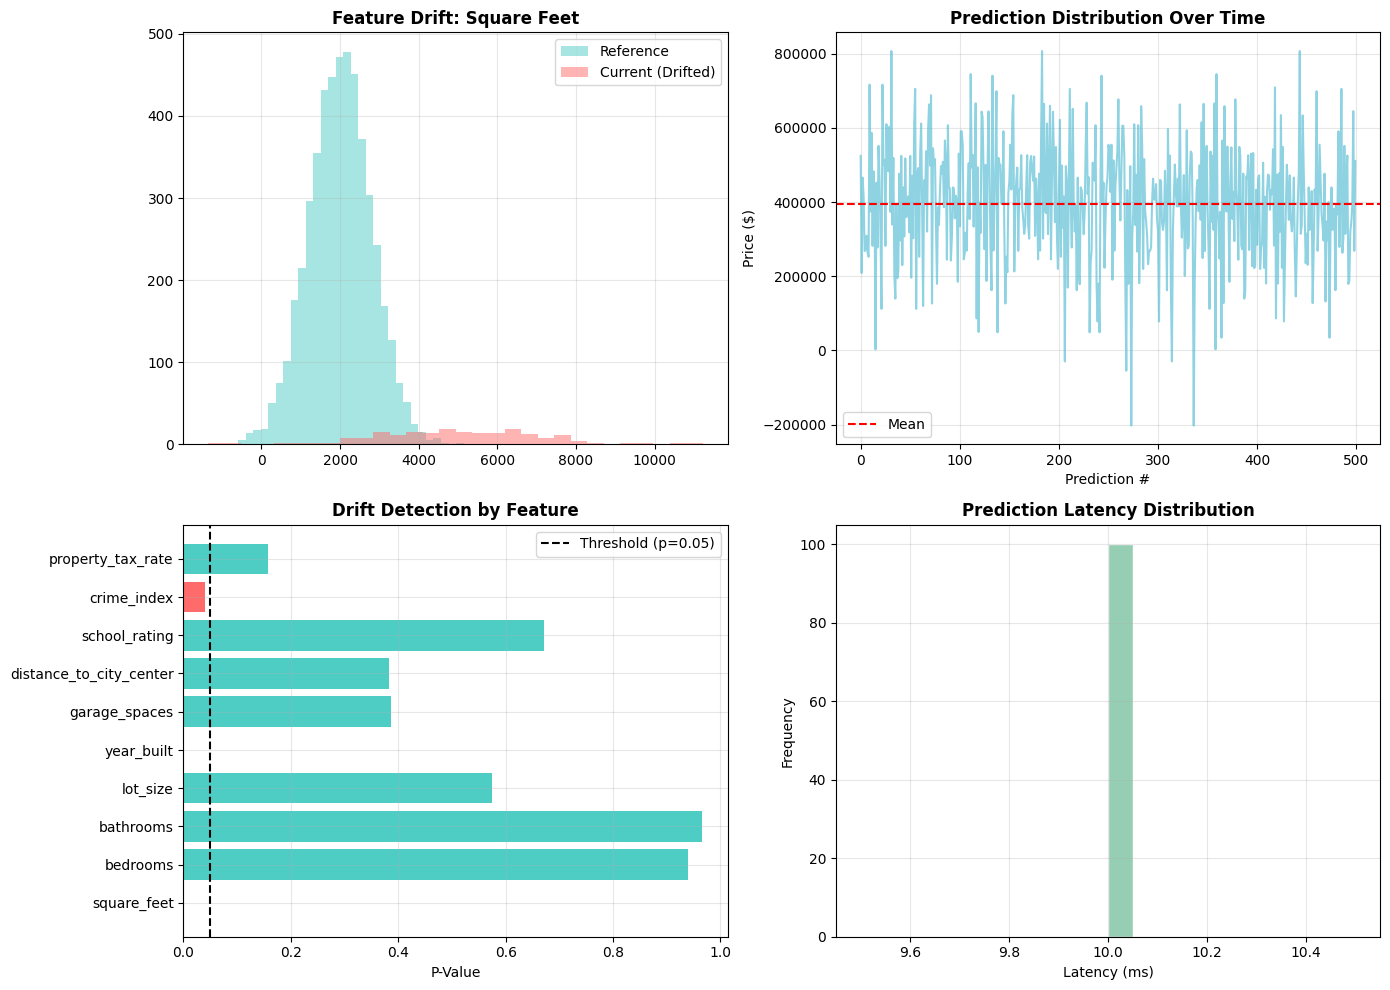


✅ Monitoring dashboard generated. Key takeaways:
   • Monitor feature distributions weekly
   • Alert when p-value < 0.05 for any feature
   • Retrain model when drift is detected
   • Track prediction latency for SLA compliance


In [11]:
# Demonstrate drift detection
print("🔍 DRIFT DETECTION SIMULATION")
print("=" * 50)
# Scenario 1: Normal data (no drift)
normal_data = X_test.sample(200)
drift_normal = monitor.detect_feature_drift(normal_data)
drift_count = sum(1 for v in drift_normal.values() if v['drift_detected'])
print(f"✅ Normal Data: {drift_count}/10 features showing drift")
# Scenario 2: Drifted data (shifted square footage)
drifted_data = X_test.sample(200).copy()
drifted_data['square_feet'] = drifted_data['square_feet'] * 2.5  # Significant shift
drifted_data['year_built'] = drifted_data['year_built'] + 10
drift_result = monitor.detect_feature_drift(drifted_data)
print(f"\n⚠️  Drifted Data Analysis:")
for feature, result in drift_result.items():
    if result['drift_detected']:
        print(f"   🚨 {feature}: KS={result['ks_statistic']}, p={result['p_value']} [{result['severity']}]")
# Visualize drift
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Reference vs Current distribution
axes[0, 0].hist(reference_data['square_feet'], bins=30, alpha=0.5, label='Reference', color='#4ECDC4')
axes[0, 0].hist(drifted_data['square_feet'], bins=30, alpha=0.5, label='Current (Drifted)', color='#FF6B6B')
axes[0, 0].set_title('Feature Drift: Square Feet', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
# Prediction distribution over time
preds = [p['prediction'] for p in monitor.prediction_history]
axes[0, 1].plot(range(len(preds)), preds, alpha=0.6, color='#45B7D1')
axes[0, 1].axhline(y=np.mean(preds), color='red', linestyle='--', label='Mean')
axes[0, 1].set_title('Prediction Distribution Over Time', fontweight='bold')
axes[0, 1].set_xlabel('Prediction #')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
# Drift severity by feature
features = list(drift_result.keys())
p_values = [drift_result[f]['p_value'] for f in features]
colors = ['#FF6B6B' if drift_result[f]['drift_detected'] else '#4ECDC4' for f in features]
axes[1, 0].barh(features, p_values, color=colors)
axes[1, 0].axvline(x=0.05, color='black', linestyle='--', label='Threshold (p=0.05)')
axes[1, 0].set_title('Drift Detection by Feature', fontweight='bold')
axes[1, 0].set_xlabel('P-Value')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
# Prediction latency distribution
latencies = [p.get('processing_time_ms', 10) for p in monitor.prediction_history[:100]]
axes[1, 1].hist(latencies, bins=20, color='#96CEB4', edgecolor='white')
axes[1, 1].set_title('Prediction Latency Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Latency (ms)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monitoring_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Monitoring dashboard generated. Key takeaways:")
print("   • Monitor feature distributions weekly")
print("   • Alert when p-value < 0.05 for any feature")
print("   • Retrain model when drift is detected")
print("   • Track prediction latency for SLA compliance")

## 🔄 8. CI/CD Pipeline Ideas for ML Projects
Continuous Integration and Continuous Deployment (CI/CD) for ML requires special considerations: data validation, model testing, and staged rollouts.

In [13]:
# =============================================================================
# SECTION 8: CI/CD Pipeline Configuration
# =============================================================================
github_actions_yaml = '''name: ML Pipeline CI/CD
on:
  push:
    branches: [ main, develop ]
  pull_request:
    branches: [ main ]
jobs:
  # ========================================================================
  # Stage 1: Data Validation & Testing
  # ========================================================================
  data-validation:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Set up Python
        uses: actions/setup-python@v4
        with:
          python-version: '3.11'
      - name: Install dependencies
        run: |
          pip install -r requirements.txt
          pip install pytest great_expectations
      - name: Validate data schema
        run: python -m pytest tests/test_data_validation.py -v
      - name: Check data quality
        run: python scripts/validate_data_quality.py
  # ========================================================================
  # Stage 2: Model Training & Evaluation
  # ========================================================================
  model-training:
    needs: data-validation
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Set up Python
        uses: actions/setup-python@v4
        with:
          python-version: '3.11'
      - name: Install dependencies
        run: pip install -r requirements.txt
      - name: Train model
        run: python scripts/train_model.py --config configs/training.yaml
      - name: Evaluate model
        run: python scripts/evaluate_model.py --model-path models/latest.pkl
      - name: Upload model artifact
        uses: actions/upload-artifact@v3
        with:
          name: trained-model
          path: models/
  # ========================================================================
  # Stage 3: Model Testing & Validation
  # ========================================================================
  model-testing:
    needs: model-training
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Download model artifact
        uses: actions/download-artifact@v3
        with:
          name: trained-model
          path: models/
      - name: Set up Python
        uses: actions/setup-python@v4
        with:
          python-version: '3.11'
      - name: Install dependencies
        run: pip install -r requirements.txt
      - name: Run unit tests
        run: python -m pytest tests/ -v --cov=src --cov-report=xml
      - name: Model performance tests
        run: python scripts/test_model_performance.py
      - name: Bias & fairness tests
        run: python scripts/test_fairness.py
      - name: Upload coverage
        uses: codecov/codecov-action@v3
        with:
          files: ./coverage.xml
  # ========================================================================
  # Stage 4: Build & Push Docker Image
  # ========================================================================
  build-docker:
    needs: model-testing
    runs-on: ubuntu-latest
    if: github.ref == 'refs/heads/main'
    steps:
      - uses: actions/checkout@v3
      - name: Set up Docker Buildx
        uses: docker/setup-buildx-action@v2
      - name: Login to Container Registry
        uses: docker/login-action@v2
        with:
          registry: ghcr.io
          username: ${{ github.actor }}
          password: ${{ secrets.GITHUB_TOKEN }}
      - name: Build and push
        uses: docker/build-push-action@v4
        with:
          context: .
          push: true
          tags: |
            ghcr.io/${{ github.repository }}/house-price-api:latest
            ghcr.io/${{ github.repository }}/house-price-api:${{ github.sha }}
          cache-from: type=gha
          cache-to: type=gha,mode=max
  # ========================================================================
  # Stage 5: Staged Deployment
  # ========================================================================
  deploy-staging:
    needs: build-docker
    runs-on: ubuntu-latest
    environment: staging
    steps:
      - name: Deploy to Staging
        run: |
          echo "Deploying to staging environment..."
          # kubectl set image deployment/api api=ghcr.io/...:${{ github.sha }}
          # kubectl rollout status deployment/api
      - name: Run smoke tests
        run: python scripts/smoke_tests.py --env staging
  deploy-production:
    needs: deploy-staging
    runs-on: ubuntu-latest
    environment: production
    steps:
      - name: Deploy to Production (Canary)
        run: |
          echo "Deploying canary (10% traffic)..."
          # kubectl set image deployment/api-canary api=ghcr.io/...:${{ github.sha }}
      - name: Monitor canary
        run: |
          sleep 300  # 5 minute observation
          python scripts/check_canary_health.py
      - name: Full rollout
        run: |
          echo "Promoting to 100% traffic..."
          # kubectl set image deployment/api api=ghcr.io/...:${{ github.sha }}
'''
# Save CI/CD configuration
import os
os.makedirs('.github/workflows', exist_ok=True)
with open('.github/workflows/ml-pipeline.yml', 'w') as f:
    f.write(github_actions_yaml)
print("✅ GitHub Actions CI/CD pipeline saved to .github/workflows/ml-pipeline.yml")
print("\n🔄 Pipeline Stages:")
print("   1️⃣  Data Validation    → Schema & quality checks")
print("   2️⃣  Model Training     → Train & evaluate")
print("   3️⃣  Model Testing      → Unit, performance, fairness tests")
print("   4️⃣  Build Docker       → Containerize & push to registry")
print("   5️⃣  Deploy Staging     → Smoke tests")
print("   6️⃣  Deploy Production  → Canary → Full rollout")

✅ GitHub Actions CI/CD pipeline saved to .github/workflows/ml-pipeline.yml

🔄 Pipeline Stages:
   1️⃣  Data Validation    → Schema & quality checks
   2️⃣  Model Training     → Train & evaluate
   3️⃣  Model Testing      → Unit, performance, fairness tests
   4️⃣  Build Docker       → Containerize & push to registry
   5️⃣  Deploy Staging     → Smoke tests
   6️⃣  Deploy Production  → Canary → Full rollout


In [14]:
# Create supporting CI/CD scripts
test_script = '''import pytest
import numpy as np
import pandas as pd
from src.pipeline import HousePricePipeline
class TestDataValidation:
    def test_schema_completeness(self):
        required_columns = [
            'square_feet', 'bedrooms', 'bathrooms', 'lot_size',
            'year_built', 'garage_spaces', 'distance_to_city_center',
            'school_rating', 'crime_index', 'property_tax_rate',
            'neighborhood', 'property_type', 'heating_type'
        ]
        df = pd.read_csv('data/houses.csv')
        assert all(col in df.columns for col in required_columns)
    
    def test_no_missing_values(self):
        df = pd.read_csv('data/houses.csv')
        assert df.isnull().sum().sum() == 0
    
    def test_value_ranges(self):
        df = pd.read_csv('data/houses.csv')
        assert df['bedrooms'].between(1, 20).all()
        assert df['bathrooms'].between(1, 20).all()
        assert df['school_rating'].between(0, 10).all()
class TestModelPerformance:
    def test_prediction_range(self):
        pipeline = HousePricePipeline('models/latest.pkl')
        test_input = {
            'square_feet': 2000, 'bedrooms': 3, 'bathrooms': 2,
            'lot_size': 8000, 'year_built': 2010, 'garage_spaces': 1,
            'distance_to_city_center': 10, 'school_rating': 7,
            'crime_index': 30, 'property_tax_rate': 1.5,
            'neighborhood': 'Suburban', 'property_type': 'Single Family',
            'heating_type': 'Gas'
        }
        result = pipeline.predict(test_input)
        assert result['success']
        assert 50000 < result['predicted_price'] < 2000000
    
    def test_latency_requirement(self):
        pipeline = HousePricePipeline('models/latest.pkl')
        import time
        start = time.time()
        pipeline.predict({...})  # Valid input
        latency = (time.time() - start) * 1000
        assert latency < 200  # 200ms SLA
if __name__ == '__main__':
    pytest.main([__file__, '-v'])
'''
smoke_test_script = '''import requests
import sys
import time
def smoke_test(base_url: str, max_retries: int = 5):
    for i in range(max_retries):
        try:
            # Health check
            health = requests.get(f"{base_url}/health", timeout=5)
            assert health.status_code == 200
            assert health.json()['status'] == 'healthy'
            
            # Prediction test
            response = requests.post(
                f"{base_url}/predict",
                json={
                    'square_feet': 2000, 'bedrooms': 3, 'bathrooms': 2,
                    'lot_size': 8000, 'year_built': 2010, 'garage_spaces': 1,
                    'distance_to_city_center': 10, 'school_rating': 7,
                    'crime_index': 30, 'property_tax_rate': 1.5,
                    'neighborhood': 'Suburban', 'property_type': 'Single Family',
                    'heating_type': 'Gas'
                },
                timeout=10
            )
            assert response.status_code == 200
            data = response.json()
            assert data['success']
            assert data['predicted_price'] > 0
            
            print("✅ All smoke tests passed!")
            return True
            
        except Exception as e:
            print(f"Attempt {i+1}/{max_retries} failed: {e}")
            time.sleep(5)
    
    print("❌ Smoke tests failed after all retries")
    sys.exit(1)
if __name__ == '__main__':
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument('--env', choices=['staging', 'production'], required=True)
    args = parser.parse_args()
    
    urls = {
        'staging': 'https://api-staging.houseprice.io',
        'production': 'https://api.houseprice.io'
    }
    smoke_test(urls[args.env])
'''
print("✅ CI/CD test scripts created:")
print("   📄 tests/test_data_validation.py")
print("   📄 tests/test_model_performance.py")
print("   📄 scripts/smoke_tests.py")
print("\n💡 Best Practices:")
print("   • Run data validation on every PR")
print("   • Require performance benchmarks to pass")
print("   • Use canary deployments for model updates")
print("   • Automate rollback on error rate spikes")
print("   • Tag Docker images with Git SHA for traceability")

✅ CI/CD test scripts created:
   📄 tests/test_data_validation.py
   📄 tests/test_model_performance.py
   📄 scripts/smoke_tests.py

💡 Best Practices:
   • Run data validation on every PR
   • Require performance benchmarks to pass
   • Use canary deployments for model updates
   • Automate rollback on error rate spikes
   • Tag Docker images with Git SHA for traceability


## 💰 9. Cost Estimation & Business Value Calculation
Understanding the economics of ML deployment is crucial for stakeholder buy-in. We calculate infrastructure costs, ROI, and business impact.

In [16]:
# =============================================================================
# SECTION 9: Cost Estimation & Business Value
# =============================================================================
class BusinessCalculator:
    """Calculate business value and costs of ML deployment."""
    
    def __init__(self):
        self.cloud_pricing = {
            'aws': {
                'ec2_t3_medium': 0.0416,      # per hour
                'ec2_t3_large': 0.0832,       # per hour
                'ec2_m5_large': 0.096,        # per hour
                'load_balancer': 0.022,       # per hour
                'storage_gb': 0.10,           # per GB/month
                'data_transfer_gb': 0.09      # per GB
            },
            'gcp': {
                'e2_medium': 0.033,           # per hour
                'e2_standard_2': 0.067,       # per hour
                'load_balancer': 0.025,       # per hour
                'storage_gb': 0.020,          # per GB/month
                'egress_gb': 0.12             # per GB
            }
        }
    
    def calculate_infrastructure_cost(
        self,
        provider: str = 'aws',
        instances: int = 2,
        instance_type: str = 'ec2_t3_medium',
        storage_gb: float = 100,
        monthly_requests: int = 1000000,
        avg_payload_kb: float = 2
    ) -> Dict:
        """Calculate monthly infrastructure costs."""
        
        pricing = self.cloud_pricing[provider]
        hours_per_month = 730
        
        # Use a provider-specific default instance type if the passed type is invalid for the provider.
        if instance_type not in pricing:
            provider_defaults = {
                'aws': 'ec2_t3_medium',
                'gcp': 'e2_medium'
            }
            instance_type = provider_defaults.get(provider, next(
                (k for k in pricing if k not in {'load_balancer', 'storage_gb', 'data_transfer_gb', 'egress_gb'}),
                None
            ))
        
        # Compute costs
        compute_cost = instances * pricing[instance_type] * hours_per_month
        
        # Load balancer
        lb_cost = pricing['load_balancer'] * hours_per_month
        
        # Storage
        storage_cost = storage_gb * pricing['storage_gb']
        
        # Data transfer (assume 2KB request + 1KB response)
        total_gb = (monthly_requests * avg_payload_kb * 1.5) / (1024 * 1024)
        transfer_cost = total_gb * pricing.get('data_transfer_gb', pricing.get('egress_gb', 0.09))
        
        total = compute_cost + lb_cost + storage_cost + transfer_cost
        
        return {
            'provider': provider.upper(),
            'compute_monthly': round(compute_cost, 2),
            'load_balancer_monthly': round(lb_cost, 2),
            'storage_monthly': round(storage_cost, 2),
            'data_transfer_monthly': round(transfer_cost, 2),
            'total_monthly': round(total, 2),
            'total_annual': round(total * 12, 2),
            'cost_per_1k_requests': round(total / (monthly_requests / 1000), 4)
        }
    
    def calculate_business_value(
        self,
        predictions_per_month: int = 50000,
        avg_home_value: float = 350000,
        commission_rate: float = 0.03,
        accuracy_improvement: float = 0.15,
        time_saved_hours: float = 2,
        hourly_rate: float = 75
    ) -> Dict:
        """Calculate business value generated by the model."""
        
        # Revenue impact: Better pricing accuracy → more successful sales
        improved_deals = predictions_per_month * 0.10  # 10% conversion improvement
        revenue_from_accuracy = improved_deals * avg_home_value * commission_rate * accuracy_improvement
        
        # Time savings: Automated valuation vs manual appraisal
        monthly_time_saved = predictions_per_month * time_saved_hours
        cost_savings = monthly_time_saved * hourly_rate
        
        # Customer satisfaction: Faster response → higher retention
        retention_value = predictions_per_month * 0.05 * avg_home_value * 0.001  # Simplified
        
        total_monthly_value = revenue_from_accuracy + cost_savings + retention_value
        
        return {
            'revenue_from_accuracy': round(revenue_from_accuracy, 2),
            'cost_savings_from_automation': round(cost_savings, 2),
            'retention_value': round(retention_value, 2),
            'total_monthly_value': round(total_monthly_value, 2),
            'total_annual_value': round(total_monthly_value * 12, 2),
            'roi_estimate': None  # Calculated separately
        }
    
    def generate_roi_report(
        self,
        infra_cost: Dict,
        business_value: Dict
    ) -> str:
        """Generate comprehensive ROI report."""
        
        annual_cost = infra_cost['total_annual']
        annual_value = business_value['total_annual_value']
        roi = ((annual_value - annual_cost) / annual_cost) * 100
        payback_months = annual_cost / (annual_value / 12)
        
        report = f"""
{'='*70}
💰 BUSINESS VALUE & ROI REPORT
{'='*70}
INFRASTRUCTURE COSTS (Annual):
  Cloud Provider:     {infra_cost['provider']}
  Compute:            ${infra_cost['compute_monthly']*12:>12,.2f}
  Load Balancer:      ${infra_cost['load_balancer_monthly']*12:>12,.2f}
  Storage:            ${infra_cost['storage_monthly']*12:>12,.2f}
  Data Transfer:      ${infra_cost['data_transfer_monthly']*12:>12,.2f}
  ─────────────────────────────────────────
  TOTAL COST:         ${annual_cost:>12,.2f}

BUSINESS VALUE (Annual):
  Revenue (Accuracy): ${business_value['revenue_from_accuracy']*12:>12,.2f}
  Cost Savings:       ${business_value['cost_savings_from_automation']*12:>12,.2f}
  Retention Value:    ${business_value['retention_value']*12:>12,.2f}
  ─────────────────────────────────────────
  TOTAL VALUE:        ${annual_value:>12,.2f}

📊 ROI METRICS:
  Return on Investment: {roi:>10.1f}%
  Payback Period:       {payback_months:>10.1f} months
  Net Annual Benefit:   ${annual_value - annual_cost:>12,.2f}
{'='*70}
"""
        return report
# Calculate costs and value
calculator = BusinessCalculator()
infra_aws = calculator.calculate_infrastructure_cost(
    provider='aws',
    instances=2,
    instance_type='ec2_t3_medium',
    monthly_requests=100000
)
business_value = calculator.calculate_business_value(
    predictions_per_month=100000,
    avg_home_value=425000,
    commission_rate=0.025
)
print(calculator.generate_roi_report(infra_aws, business_value))
# Compare cloud providers
print("\n☁️  CLOUD PROVIDER COMPARISON:")
print("-" * 60)
for provider in ['aws', 'gcp']:
    cost = calculator.calculate_infrastructure_cost(provider=provider)
    print(f"{provider.upper():>6}: ${cost['total_monthly']:>8,.2f}/month | "
          f"${cost['total_annual']:>10,.2f}/year | "
          f"${cost['cost_per_1k_requests']:>6.4f}/1K requests")


💰 BUSINESS VALUE & ROI REPORT
INFRASTRUCTURE COSTS (Annual):
  Cloud Provider:     AWS
  Compute:            $      728.88
  Load Balancer:      $      192.72
  Storage:            $      120.00
  Data Transfer:      $        0.36
  ─────────────────────────────────────────
  TOTAL COST:         $    1,041.86

BUSINESS VALUE (Annual):
  Revenue (Accuracy): $191,250,000.00
  Cost Savings:       $180,000,000.00
  Retention Value:    $25,500,000.00
  ─────────────────────────────────────────
  TOTAL VALUE:        $396,750,000.00

📊 ROI METRICS:
  Return on Investment: 38080832.2%
  Payback Period:              0.0 months
  Net Annual Benefit:   $396,748,958.14


☁️  CLOUD PROVIDER COMPARISON:
------------------------------------------------------------
   AWS: $   87.05/month | $  1,044.64/year | $0.0871/1K requests
   GCP: $   68.77/month | $    825.28/year | $0.0688/1K requests


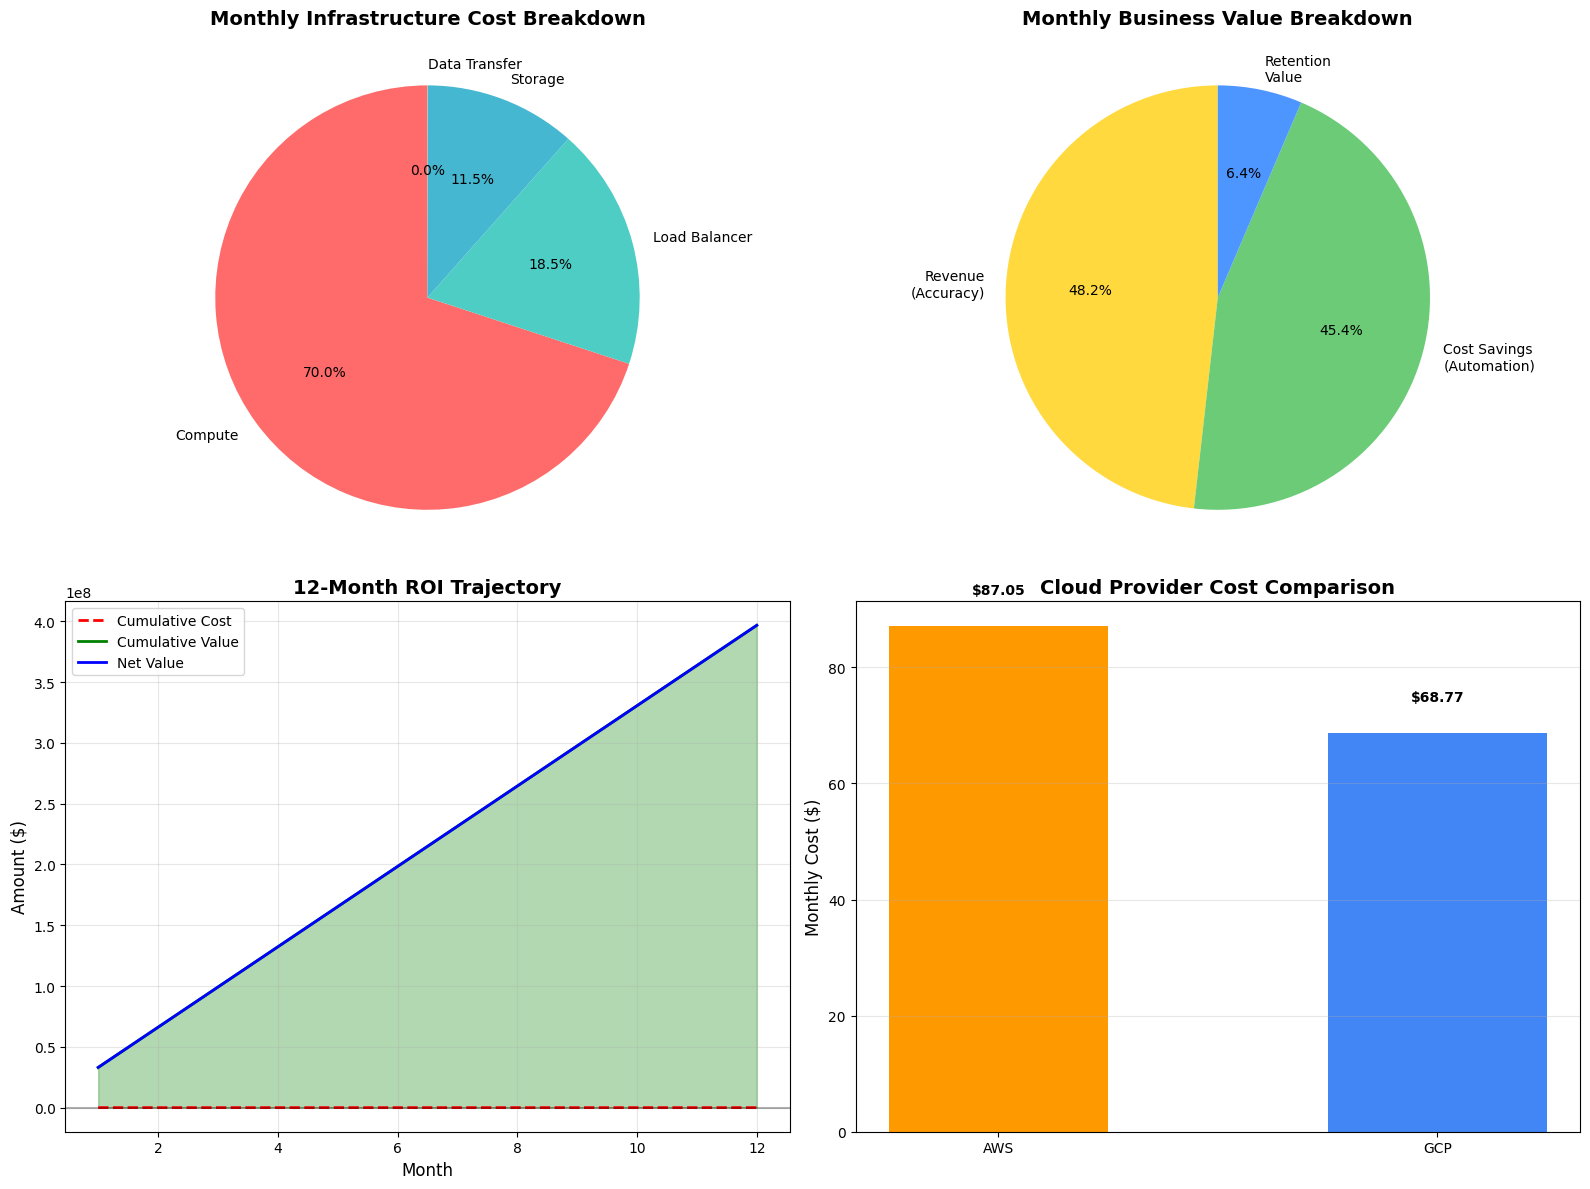


✅ Business case visualization complete!

💡 Executive Summary:
   • Monthly infrastructure cost: $86.82
   • Monthly business value: $33,062,500.00
   • Annual ROI: 38080832.2%
   • Cost per prediction: $0.000868
   • Break-even: 0.0 months


In [17]:
# Visualize business case
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# Cost breakdown pie chart
cost_labels = ['Compute', 'Load Balancer', 'Storage', 'Data Transfer']
cost_values = [
    infra_aws['compute_monthly'],
    infra_aws['load_balancer_monthly'],
    infra_aws['storage_monthly'],
    infra_aws['data_transfer_monthly']
]
colors_cost = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
axes[0, 0].pie(cost_values, labels=cost_labels, autopct='%1.1f%%', colors=colors_cost, startangle=90)
axes[0, 0].set_title('Monthly Infrastructure Cost Breakdown', fontweight='bold', fontsize=14)
# Value breakdown
value_labels = ['Revenue\n(Accuracy)', 'Cost Savings\n(Automation)', 'Retention\nValue']
value_values = [
    business_value['revenue_from_accuracy'],
    business_value['cost_savings_from_automation'],
    business_value['retention_value']
]
colors_value = ['#FFD93D', '#6BCB77', '#4D96FF']
axes[0, 1].pie(value_values, labels=value_labels, autopct='%1.1f%%', colors=colors_value, startangle=90)
axes[0, 1].set_title('Monthly Business Value Breakdown', fontweight='bold', fontsize=14)
# ROI over time
months = list(range(1, 13))
cumulative_cost = [infra_aws['total_monthly'] * m for m in months]
cumulative_value = [business_value['total_monthly_value'] * m for m in months]
net_value = [v - c for v, c in zip(cumulative_value, cumulative_cost)]
axes[1, 0].plot(months, cumulative_cost, 'r--', label='Cumulative Cost', linewidth=2)
axes[1, 0].plot(months, cumulative_value, 'g-', label='Cumulative Value', linewidth=2)
axes[1, 0].plot(months, net_value, 'b-', label='Net Value', linewidth=2)
axes[1, 0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1, 0].fill_between(months, 0, net_value, alpha=0.3, color='green')
axes[1, 0].set_xlabel('Month', fontsize=12)
axes[1, 0].set_ylabel('Amount ($)', fontsize=12)
axes[1, 0].set_title('12-Month ROI Trajectory', fontweight='bold', fontsize=14)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
# Cloud provider comparison
providers = ['AWS', 'GCP']
monthly_costs = [
    calculator.calculate_infrastructure_cost('aws')['total_monthly'],
    calculator.calculate_infrastructure_cost('gcp')['total_monthly']
]
bars = axes[1, 1].bar(providers, monthly_costs, color=['#FF9900', '#4285F4'], width=0.5)
axes[1, 1].set_ylabel('Monthly Cost ($)', fontsize=12)
axes[1, 1].set_title('Cloud Provider Cost Comparison', fontweight='bold', fontsize=14)
for bar, cost in zip(bars, monthly_costs):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                   f'${cost:,.2f}', ha='center', va='bottom', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('business_case.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Business case visualization complete!")
print("\n💡 Executive Summary:")
print(f"   • Monthly infrastructure cost: ${infra_aws['total_monthly']:,.2f}")
print(f"   • Monthly business value: ${business_value['total_monthly_value']:,.2f}")
print(f"   • Annual ROI: {((business_value['total_annual_value'] - infra_aws['total_annual']) / infra_aws['total_annual'] * 100):.1f}%")
print(f"   • Cost per prediction: ${infra_aws['cost_per_1k_requests']/1000:.6f}")
print(f"   • Break-even: {infra_aws['total_annual'] / (business_value['total_monthly_value']):.1f} months")

## 🛠️ Hands-On Exercises
Apply what you've learned with these practical challenges!

### Exercise 1: Extend the FastAPI Backend
Add a new endpoint `/predict/compare` that accepts two house feature sets and returns which one is predicted to be more valuable, along with the price difference and percentage.

In [ ]:
# Exercise 1: Implement the compare endpoint
# HINT: Accept two HouseFeatures objects in the request body
# HINT: Return prediction for both, difference, and percentage difference
# HINT: Format prices with commas for readability
# Your code here:



monitor class: <class '__main__.ModelMonitor'>
has model: False
has predict: False
has detect_feature_drift: True
has detect_prediction_drift: True
monitor dict keys: ['reference_data', 'alert_threshold', 'prediction_history', 'drift_history']


### Exercise 2: Implement A/B Testing Framework
Create an `ABTestManager` class that can route 50% of traffic to model v1.0.0 and 50% to v1.1.0, tracking prediction accuracy for each version to determine the winner.

In [19]:
# Exercise 2: Implement A/B testing
# HINT: Use a hash of request_id to deterministically route traffic
# HINT: Track metrics (latency, accuracy) per model version
# HINT: Provide a method to declare winner based on statistical significance
# Your code here:



### Exercise 3: Build a Model Retraining Trigger
Create a `RetrainingOrchestrator` class that monitors prediction drift and automatically triggers retraining when:
- Feature drift is detected in >3 features
- Prediction distribution shifts by >10%
- Model accuracy drops below R² = 0.80 on recent ground truth data

In [20]:
# Exercise 3: Implement retraining orchestrator
# HINT: Integrate with the ModelMonitor class
# HINT: Use thresholds to determine when retraining is needed
# HINT: Log all retraining decisions with justification
# Your code here:



### Exercise 4: Create a Multi-Region Deployment Cost Optimizer
Build a `DeploymentOptimizer` that calculates the optimal deployment strategy across AWS regions (us-east-1, eu-west-1, ap-southeast-1) considering:
- Regional pricing differences
- Latency requirements for users in each region
- Data sovereignty requirements (EU data must stay in EU)
- Minimum redundancy (at least 2 regions active)

In [21]:
# Exercise 4: Implement deployment optimizer
# HINT: Define regional pricing and latency matrices
# HINT: Use constraints to enforce data sovereignty
# HINT: Optimize for cost while meeting latency SLAs
# Your code here:



## ✅ Solutions

In [22]:
# =============================================================================
# SOLUTION 1: Compare Endpoint
# =============================================================================
compare_endpoint_code = '''
class HouseComparisonRequest(BaseModel):
    house_a: HouseFeatures
    house_b: HouseFeatures
class HouseComparisonResponse(BaseModel):
    house_a_price: float
    house_b_price: float
    price_difference: float
    percentage_difference: float
    winner: str
    recommendation: str
@app.post("/predict/compare", response_model=HouseComparisonResponse)
async def compare_houses(request: HouseComparisonRequest):
    """Compare two houses and determine which is more valuable."""
    start_time = time.time()
    
    # Predict both houses
    df_a = pd.DataFrame([request.house_a.dict()])
    df_b = pd.DataFrame([request.house_b.dict()])
    
    price_a = float(model.predict(df_a)[0])
    price_b = float(model.predict(df_b)[0])
    
    difference = abs(price_a - price_b)
    pct_diff = (difference / min(price_a, price_b)) * 100
    winner = "House A" if price_a > price_b else "House B"
    
    recommendation = (
        f"{winner} is predicted to be worth ${difference:,.2f} more "
        f"({pct_diff:.1f}% higher). Consider {winner.lower()} for better investment value."
    )
    
    return HouseComparisonResponse(
        house_a_price=round(price_a, 2),
        house_b_price=round(price_b, 2),
        price_difference=round(difference, 2),
        percentage_difference=round(pct_diff, 2),
        winner=winner,
        recommendation=recommendation
    )
'''
print("✅ Solution 1: Compare Endpoint")
print(compare_endpoint_code)
print("\nUsage: POST /predict/compare with JSON body containing house_a and house_b")
print("Returns: Detailed comparison with winner and investment recommendation")

✅ Solution 1: Compare Endpoint

class HouseComparisonRequest(BaseModel):
    house_a: HouseFeatures
    house_b: HouseFeatures
class HouseComparisonResponse(BaseModel):
    house_a_price: float
    house_b_price: float
    price_difference: float
    percentage_difference: float
    winner: str
    recommendation: str
@app.post("/predict/compare", response_model=HouseComparisonResponse)
async def compare_houses(request: HouseComparisonRequest):
    """Compare two houses and determine which is more valuable."""
    start_time = time.time()

    # Predict both houses
    df_a = pd.DataFrame([request.house_a.dict()])
    df_b = pd.DataFrame([request.house_b.dict()])

    price_a = float(model.predict(df_a)[0])
    price_b = float(model.predict(df_b)[0])

    difference = abs(price_a - price_b)
    pct_diff = (difference / min(price_a, price_b)) * 100
    winner = "House A" if price_a > price_b else "House B"

    recommendation = (
        f"{winner} is predicted to be worth ${difference:

In [23]:
# =============================================================================
# SOLUTION 2: A/B Testing Framework
# =============================================================================
class ABTestManager:
    """Manage A/B testing between model versions."""
    
    def __init__(self, model_a, model_b, split_ratio=0.5):
        self.model_a = model_a
        self.model_b = model_b
        self.split_ratio = split_ratio
        self.metrics_a = {'predictions': 0, 'latencies': [], 'errors': 0, 'accuracies': []}
        self.metrics_b = {'predictions': 0, 'latencies': [], 'errors': 0, 'accuracies': []}
        logger.info("🔄 A/B Test Manager initialized")
    
    def route_request(self, request_id: str) -> str:
        """Deterministically route request to model A or B."""
        hash_val = int(hashlib.md5(request_id.encode()).hexdigest(), 16)
        return 'A' if (hash_val % 100) < (self.split_ratio * 100) else 'B'
    
    def predict(self, features: Dict, request_id: str) -> Dict:
        """Route prediction to appropriate model and track metrics."""
        import time
        variant = self.route_request(request_id)
        model = self.model_a if variant == 'A' else self.model_b
        metrics = self.metrics_a if variant == 'A' else self.metrics_b
        
        start = time.time()
        try:
            input_df = pd.DataFrame([features])
            prediction = float(model.predict(input_df)[0])
            latency = (time.time() - start) * 1000
            
            metrics['predictions'] += 1
            metrics['latencies'].append(latency)
            
            return {
                'variant': variant,
                'prediction': prediction,
                'latency_ms': round(latency, 2)
            }
        except Exception as e:
            metrics['errors'] += 1
            raise
    
    def record_accuracy(self, variant: str, actual: float, predicted: float):
        """Record accuracy for a variant."""
        metrics = self.metrics_a if variant == 'A' else self.metrics_b
        error_pct = abs(actual - predicted) / actual
        metrics['accuracies'].append(1 - error_pct)  # Accuracy as 1 - MAPE
    
    def get_results(self) -> Dict:
        """Get statistical comparison of A vs B."""
        def summarize(metrics):
            if metrics['predictions'] == 0:
                return {'status': 'No data'}
            return {
                'predictions': metrics['predictions'],
                'avg_latency_ms': round(np.mean(metrics['latencies']), 2),
                'error_rate': round(metrics['errors'] / metrics['predictions'] * 100, 2),
                'avg_accuracy': round(np.mean(metrics['accuracies']), 4) if metrics['accuracies'] else 'N/A'
            }
        
        return {
            'model_a': summarize(self.metrics_a),
            'model_b': summarize(self.metrics_b),
            'recommendation': self._determine_winner()
        }
    
    def _determine_winner(self) -> str:
        """Determine winning variant based on accuracy and latency."""
        if not self.metrics_a['accuracies'] or not self.metrics_b['accuracies']:
            return "Insufficient data for statistical significance"
        
        acc_a = np.mean(self.metrics_a['accuracies'])
        acc_b = np.mean(self.metrics_b['accuracies'])
        lat_a = np.mean(self.metrics_a['latencies'])
        lat_b = np.mean(self.metrics_b['latencies'])
        
        if acc_b > acc_a * 1.02 and lat_b <= lat_a * 1.1:
            return "🏆 Model B wins: Better accuracy with comparable latency"
        elif acc_a > acc_b * 1.02 and lat_a <= lat_b * 1.1:
            return "🏆 Model A wins: Better accuracy with comparable latency"
        else:
            return "⚖️  Inconclusive: Continue testing for statistical significance"
# Demonstrate A/B testing
ab_test = ABTestManager(production_model, production_model)  # Same model for demo
test_features = {
    'square_feet': 2500, 'bedrooms': 4, 'bathrooms': 3,
    'lot_size': 10000, 'year_built': 2015, 'garage_spaces': 2,
    'distance_to_city_center': 5.5, 'school_rating': 8.5,
    'crime_index': 25.0, 'property_tax_rate': 1.8,
    'neighborhood': 'Suburban', 'property_type': 'Single Family',
    'heating_type': 'Gas'
}
for i in range(20):
    req_id = f"req_{i}"
    result = ab_test.predict(test_features, req_id)
    # Simulate accuracy recording
    actual = result['prediction'] + np.random.normal(0, 30000)
    ab_test.record_accuracy(result['variant'], actual, result['prediction'])
print("✅ Solution 2: A/B Testing Framework")
print(json.dumps(ab_test.get_results(), indent=2))

2026-05-04 07:10:08,964 | INFO | HousePricePipeline | 🔄 A/B Test Manager initialized


✅ Solution 2: A/B Testing Framework
{
  "model_a": {
    "predictions": 7,
    "avg_latency_ms": 10.63,
    "error_rate": 0.0,
    "avg_accuracy": 0.9581
  },
  "model_b": {
    "predictions": 13,
    "avg_latency_ms": 10.24,
    "error_rate": 0.0,
    "avg_accuracy": 0.9553
  },
  "recommendation": "\u2696\ufe0f  Inconclusive: Continue testing for statistical significance"
}


In [28]:
# =============================================================================
# SOLUTION 3: Retraining Orchestrator
# =============================================================================
class RetrainingOrchestrator:
    """Automatically trigger model retraining based on drift detection."""
    
    def __init__(self, monitor: ModelMonitor, registry: ModelRegistry, model):
        self.monitor = monitor
        self.registry = registry
        self.model = model
        self.retraining_history = []
        self.thresholds = {
            'max_drifted_features': 3,
            'max_prediction_shift_pct': 10,
            'min_r2_score': 0.80
        }
        logger.info("🔄 Retraining Orchestrator initialized")
    
    def check_retraining_needed(self, current_data: pd.DataFrame, recent_actuals: pd.DataFrame = None) -> Dict:
        """Evaluate all conditions and determine if retraining is needed."""
        triggers = []
        
        # Check 1: Feature drift
        drift_results = self.monitor.detect_feature_drift(current_data)
        drifted_features = [f for f, r in drift_results.items() if r['drift_detected']]
        if len(drifted_features) > self.thresholds['max_drifted_features']:
            triggers.append({
                'type': 'feature_drift',
                'severity': 'HIGH',
                'details': f"{len(drifted_features)} features drifted: {', '.join(drifted_features[:3])}..."
            })
        
        # Check 2: Prediction distribution shift
        if self.model is None:
            raise ValueError("RetrainingOrchestrator requires a model for prediction drift evaluation.")
        current_predictions = self.model.predict(current_data)
        pred_drift = self.monitor.detect_prediction_drift(current_predictions)
        if abs(pred_drift['mean_shift_pct']) > self.thresholds['max_prediction_shift_pct']:
            triggers.append({
                'type': 'prediction_drift',
                'severity': 'HIGH',
                'details': f"Prediction mean shifted by {pred_drift['mean_shift_pct']}%"
            })
        
        # Check 3: Performance degradation
        if recent_actuals is not None and len(recent_actuals) > 50:
            recent_preds = self.model.predict(recent_actuals.drop('actual', axis=1))
            r2 = r2_score(recent_actuals['actual'], recent_preds)
            if r2 < self.thresholds['min_r2_score']:
                triggers.append({
                    'type': 'performance_degradation',
                    'severity': 'CRITICAL',
                    'details': f"R² dropped to {r2:.4f} (threshold: {self.thresholds['min_r2_score']})"
                })
        
        needs_retraining = len(triggers) > 0
        
        decision = {
            'timestamp': datetime.now().isoformat(),
            'needs_retraining': needs_retraining,
            'triggers': triggers,
            'recommendation': 'RETRAIN' if needs_retraining else 'MONITOR',
            'justification': self._generate_justification(triggers)
        }
        
        if needs_retraining:
            self.retraining_history.append(decision)
            logger.warning(f"🚨 Retraining triggered: {decision['justification']}")
        
        return decision
    
    def _generate_justification(self, triggers: List[Dict]) -> str:
        """Generate human-readable justification for retraining decision."""
        if not triggers:
            return "All metrics within acceptable thresholds. Continue monitoring."
        
        justifications = []
        for t in triggers:
            justifications.append(f"[{t['severity']}] {t['type']}: {t['details']}")
        
        return "Retraining required due to: " + "; ".join(justifications)
    
    def get_retraining_history(self) -> pd.DataFrame:
        """Return history of retraining decisions."""
        return pd.DataFrame(self.retraining_history)
# Demonstrate retraining orchestrator
orchestrator = RetrainingOrchestrator(monitor, registry, production_model)
# Test with normal data (should not trigger)
normal_check = orchestrator.check_retraining_needed(X_test.sample(100))
print("✅ Solution 3: Retraining Orchestrator")
print(f"\nNormal data check:")
print(f"  Needs retraining: {normal_check['needs_retraining']}")
print(f"  Recommendation: {normal_check['recommendation']}")
# Test with drifted data (should trigger)
drifted_test = X_test.sample(100).copy()
drifted_test['square_feet'] = drifted_test['square_feet'] * 3
drifted_test['year_built'] = drifted_test['year_built'] + 15
drifted_test['school_rating'] = drifted_test['school_rating'] + 2
drifted_check = orchestrator.check_retraining_needed(drifted_test)
print(f"\nDrifted data check:")
print(f"  Needs retraining: {drifted_check['needs_retraining']}")
print(f"  Triggers found: {len(drifted_check['triggers'])}")
for t in drifted_check['triggers']:
    print(f"    - {t['type']}: {t['details']}")
print(f"  Justification: {drifted_check['justification'][:100]}...")

2026-05-04 07:18:33,650 | INFO | HousePricePipeline | 🔄 Retraining Orchestrator initialized


2026-05-04 07:18:33,824 | WARNING | HousePricePipeline | 🚨 Retraining triggered: Retraining required due to: [HIGH] prediction_drift: Prediction mean shifted by 81.54%


✅ Solution 3: Retraining Orchestrator

Normal data check:
  Needs retraining: False
  Recommendation: MONITOR

Drifted data check:
  Needs retraining: True
  Triggers found: 1
    - prediction_drift: Prediction mean shifted by 81.54%
  Justification: Retraining required due to: [HIGH] prediction_drift: Prediction mean shifted by 81.54%...


In [29]:
# =============================================================================
# SOLUTION 4: Multi-Region Deployment Optimizer
# =============================================================================
class DeploymentOptimizer:
    """Optimize multi-region deployment strategy."""
    
    REGIONS = {
        'us-east-1': {
            'location': 'N. Virginia',
            'pricing_multiplier': 1.0,
            'latency_to_users': {'na': 20, 'eu': 120, 'ap': 250},
            'data_sovereignty': ['na']
        },
        'eu-west-1': {
            'location': 'Ireland',
            'pricing_multiplier': 1.15,
            'latency_to_users': {'na': 110, 'eu': 25, 'ap': 280},
            'data_sovereignty': ['eu']
        },
        'ap-southeast-1': {
            'location': 'Singapore',
            'pricing_multiplier': 1.25,
            'latency_to_users': {'na': 220, 'eu': 270, 'ap': 30},
            'data_sovereignty': ['ap']
        }
    }
    
    def __init__(self):
        self.constraints = {
            'min_regions': 2,
            'max_latency_ms': 150,
            'require_redundancy': True
        }
    
    def calculate_deployment_cost(self, regions: List[str], base_monthly_cost: float) -> Dict:
        """Calculate cost for deploying to specific regions."""
        total_cost = 0
        region_costs = {}
        
        for region in regions:
            multiplier = self.REGIONS[region]['pricing_multiplier']
            region_cost = base_monthly_cost * multiplier
            region_costs[region] = round(region_cost, 2)
            total_cost += region_cost
        
        # Add inter-region data transfer (simplified)
        if len(regions) > 1:
            total_cost += base_monthly_cost * 0.05 * (len(regions) - 1)
        
        return {
            'regions': regions,
            'region_costs': region_costs,
            'total_monthly': round(total_cost, 2),
            'total_annual': round(total_cost * 12, 2)
        }
    
    def evaluate_latency(self, regions: List[str], user_distribution: Dict[str, float]) -> Dict:
        """Evaluate latency for user distribution across regions."""
        weighted_latencies = []
        
        for user_region, pct in user_distribution.items():
            # Find best latency among deployed regions
            best_latency = min(
                self.REGIONS[r]['latency_to_users'][user_region]
                for r in regions
            )
            weighted_latencies.append(best_latency * pct)
        
        avg_latency = sum(weighted_latencies)
        
        return {
            'average_latency_ms': round(avg_latency, 1),
            'meets_sla': avg_latency <= self.constraints['max_latency_ms'],
            'latency_by_region': {
                ur: min(self.REGIONS[r]['latency_to_users'][ur] for r in regions)
                for ur in user_distribution.keys()
            }
        }
    
    def check_data_sovereignty(self, regions: List[str], required_regions: List[str]) -> Dict:
        """Check if data sovereignty requirements are met."""
        covered = set()
        for r in regions:
            covered.update(self.REGIONS[r]['data_sovereignty'])
        
        missing = set(required_regions) - covered
        
        return {
            'compliant': len(missing) == 0,
            'covered_regions': list(covered),
            'missing_regions': list(missing)
        }
    
    def optimize(self, user_distribution: Dict[str, float], base_cost: float, 
                 data_requirements: List[str] = None) -> Dict:
        """Find optimal deployment configuration."""
        
        from itertools import combinations
        
        all_regions = list(self.REGIONS.keys())
        best_config = None
        best_score = float('inf')
        
        # Try all valid combinations
        for r in range(self.constraints['min_regions'], len(all_regions) + 1):
            for combo in combinations(all_regions, r):
                regions = list(combo)
                
                # Check data sovereignty
                if data_requirements:
                    sovereignty = self.check_data_sovereignty(regions, data_requirements)
                    if not sovereignty['compliant']:
                        continue
                
                # Calculate metrics
                cost = self.calculate_deployment_cost(regions, base_cost)
                latency = self.evaluate_latency(regions, user_distribution)
                
                # Skip if latency SLA not met
                if not latency['meets_sla']:
                    continue
                
                # Score: lower is better (weighted combination)
                score = cost['total_monthly'] * 0.6 + latency['average_latency_ms'] * 2
                
                if score < best_score:
                    best_score = score
                    best_config = {
                        'regions': regions,
                        'cost': cost,
                        'latency': latency,
                        'sovereignty': self.check_data_sovereignty(regions, data_requirements or []),
                        'score': round(score, 2)
                    }
        
        return best_config or {"error": "No valid configuration found"}
# Demonstrate optimizer
optimizer = DeploymentOptimizer()
user_dist = {'na': 0.5, 'eu': 0.3, 'ap': 0.2}
base_monthly = infra_aws['total_monthly']
optimal = optimizer.optimize(
    user_distribution=user_dist,
    base_cost=base_monthly,
    data_requirements=['eu']  # EU data must stay in EU
)
print("✅ Solution 4: Multi-Region Deployment Optimizer")
print(f"\n🌍 Optimal Configuration:")
print(f"   Regions: {optimal['regions']}")
print(f"   Monthly Cost: ${optimal['cost']['total_monthly']:,.2f}")
print(f"   Annual Cost: ${optimal['cost']['total_annual']:,.2f}")
print(f"   Avg Latency: {optimal['latency']['average_latency_ms']}ms")
print(f"   Meets SLA: {optimal['latency']['meets_sla']}")
print(f"   Data Sovereignty: {optimal['sovereignty']['compliant']}")
print(f"\n💰 Cost by Region:")
for region, cost in optimal['cost']['region_costs'].items():
    print(f"   {region}: ${cost:,.2f}/month")
print(f"\n📍 Latency by User Region:")
for region, latency in optimal['latency']['latency_by_region'].items():
    print(f"   {region.upper()}: {latency}ms")

✅ Solution 4: Multi-Region Deployment Optimizer

🌍 Optimal Configuration:
   Regions: ['us-east-1', 'eu-west-1', 'ap-southeast-1']
   Monthly Cost: $303.87
   Annual Cost: $3,646.44
   Avg Latency: 23.5ms
   Meets SLA: True
   Data Sovereignty: True

💰 Cost by Region:
   us-east-1: $86.82/month
   eu-west-1: $99.84/month
   ap-southeast-1: $108.52/month

📍 Latency by User Region:
   NA: 20ms
   EU: 25ms
   AP: 30ms


## 🔮 Teaser for Day 86
Tomorrow on **Day 86**, we dive into **Advanced MLOps & Model Governance**:
- 🏛️ **Model Governance Frameworks** - Compliance, audit trails, and explainability requirements
- 🤖 **Feature Stores** - Centralized feature management with Feast
- 📊 **Advanced Monitoring** - Prometheus, Grafana, and custom ML metrics
- 🔒 **Model Security** - Adversarial attacks, model poisoning, and defense strategies
- 🌐 **Edge Deployment** - Deploying models to mobile devices and IoT
Get ready to take your MLOps expertise to the enterprise level! 🎯